# MULTIVARIATE TIME-SERIES REGRESSION

## Define Problem

This coursework addresses a supervised multivariate time-series regression problem using the UCI Appliances Energy Prediction dataset.

- **Goal:** Predict household appliance energy consumption from past multivariate sensor readings.
- **Input:** A chronological lookback window containing indoor temperature, indoor humidity, outdoor weather, lighting and other registered historical variables.
- **Target:** `Appliances`, measured in watt-hours (`Wh`).
- **Forecast horizon:** One step ahead, equivalent to 10 minutes.
- **Sample definition:** $X[t-L+1:t] \rightarrow Appliances[t+1]$, where $L$ is the registered lookback length.
- **Task type:** Sequence-to-one regression.
- **Model comparison:** Persistence baseline, LSTM baseline and Transformer Encoder regression model.
- **Evaluation:** MAE, RMSE and $R^2$ on the original `Wh` scale, using chronological Train, Validation and Test partitions.
- **Interpretability extension:** Analyze Transformer attention maps to inspect which historical time steps receive attention.
- **Integrity constraints:** Preserve temporal order, fit data transformations on Train only, prevent future leakage and reserve Test for final evaluation.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve() / "src"))

In [2]:
from IPython.display import Image, display

from course_work.baselines.persistence import materialize_phase_14
from course_work.utils.environment import materialize_phase_1
from course_work.data.acquisition import materialize_phase_2
from course_work.data.feature_sets import materialize_phase_8
from course_work.data.features import materialize_phase_7
from course_work.data.scaling import materialize_phase_9
from course_work.data.schema import materialize_phase_3
from course_work.data.splitting import materialize_phase_5
from course_work.data.temporal import load_validated_temporal_view, materialize_phase_4
from course_work.data.windows import materialize_phase_10
from course_work.data.datasets import materialize_phase_11
from course_work.evaluation.metrics import materialize_phase_12
from course_work.experiments.registry import materialize_phase_13
from course_work.reporting.eda import materialize_phase_6
from course_work.reporting.phase_summary import render_all_logs_summary, render_dataframe_table, render_phase_summary
from course_work.models.lstm_regressor import materialize_phase_15
from course_work.models.transformer_regressor import materialize_phase_16
from course_work.attention.verification import materialize_phase_17
from course_work.sanity.forward_sanity import materialize_phase_18
from course_work.training.engine_materialize import materialize_phase_19
from course_work.baselines.lstm_baseline import materialize_phase_20
from course_work.baselines.transformer_b0 import materialize_phase_21
from course_work.diagnostics.learning_diagnostics import materialize_phase_22
from course_work.phase_42_46 import (
    materialize_phase_42,
    materialize_phase_43,
    materialize_phase_44,
    materialize_phase_45,
    materialize_phase_46,
)
from course_work.sweeps.sweep_results import (
    materialize_phase_23,
    materialize_phase_24,
    materialize_phase_25,
    materialize_phase_26,
    materialize_phase_27,
    materialize_phase_28,
    materialize_phase_29,
    materialize_phase_30,
)
from course_work.utils.artifacts import get_project_root, read_json

PROJECT_ROOT = get_project_root()

## Phase 1 - Environment

Verify the interpreter, notebook kernel, dependency versions, compute device, deterministic configuration and training smoke test.

In [3]:
phase_1_signoff = materialize_phase_1(PROJECT_ROOT)
display(render_phase_summary(1, PROJECT_ROOT))

[ENV] GPU detected: mps | Apple Silicon MPS


Field,Value
Python,3.10.21
Kernel,coursework-venv
Kernel matches interpreter,PASS
Selected device,mps
Deterministic mode,D0
Default dtype,torch.float32
Package,Version
ipykernel,7.3.0
jupyter,1.1.1
matplotlib,3.10.9


## Phase 2 - Data Acquisition

Verify canonical UCI provenance, immutable raw bytes, archive membership, dataset metadata and acquisition sign-off without fetching data from the notebook.

In [4]:
phase_2_signoff = materialize_phase_2(PROJECT_ROOT)
display(render_phase_summary(2, PROJECT_ROOT))

[ENV] GPU detected: mps | Apple Silicon MPS


Field,Value
Dataset,Appliances Energy Prediction
Provider,UCI Machine Learning Repository
License,CC BY 4.0
Instances,19735
Reported features,28
Sampling interval,10 minutes


## Phase 3 - Schema Audit

Audit shape, column order, types, missingness, finite values, timestamp parseability and documented differences between UCI metadata and the canonical raw file.

In [5]:
phase_3_signoff = materialize_phase_3(PROJECT_ROOT)
display(render_phase_summary(3, PROJECT_ROOT))

[ENV] GPU detected: mps | Apple Silicon MPS


Field,Value
Rows,19735
Columns,29
Target,Appliances
Timestamp,date
First timestamp,2016-01-11 17:00:00
Last timestamp,2016-05-27 18:00:00
Check,Result
Missing expected columns,None
Unexpected columns,None
Duplicate column names,None


## Phase 4 - Temporal Integrity Audit

Verify strict timestamp parsing, ordering, duplicates, ten-minute cadence, missing timestamps, continuity segments and window-safety rules.

In [6]:
phase_4_signoff = materialize_phase_4(PROJECT_ROOT)
display(render_phase_summary(4, PROJECT_ROOT))

[ENV] GPU detected: mps | Apple Silicon MPS


Field,Value
Rows,19735
Start,2016-01-11 17:00:00
End,2016-05-27 18:00:00
Expected cadence,10 minutes
Coverage completeness,100.00%
Check,Result
Duplicate timestamps,0
Missing timestamps,0
Gaps,0
Largest gap in minutes,Not applicable


## Phase 5 - Chronological Split

Assign every signed TEMPORAL-v1 row to fixed chronological Train, Validation or Test target periods, preserve WB0 context-carry-over support, prepare WB1 metadata, compute structural fingerprints and lock Test until final evaluation. Phase 5 runs before EDA, Feature Engineering and Feature-Set Variants so all later phases are TRAIN-only scoped.

In [7]:
phase_5_signoff = materialize_phase_5(PROJECT_ROOT)
display(render_phase_summary(5, PROJECT_ROOT))

Split,Rows,Ratio,Start,End,Duration in minutes
Train,13814,70.00%,2016-01-11 17:00:00,2016-04-16 15:10:00,138130
Validation,2960,15.00%,2016-04-16 15:20:00,2016-05-07 04:30:00,29590
Test,2961,15.00%,2016-05-07 04:40:00,2016-05-27 18:00:00,29600


## Phase 6 - Exploratory Data Analysis

Combine signed EDA-v1 outputs with direct exploratory notebook views requested by the Human. Direct EDA uses the validated Phase 5 Train-only subset and does not write or replace canonical data.

In [8]:
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

def display_figure(figure):
    buffer = BytesIO()
    figure.savefig(buffer, format="png", bbox_inches="tight")
    plt.close(figure)
    display(Image(data=buffer.getvalue()))

sns.set_theme(style="whitegrid")
phase_6_signoff = materialize_phase_6(PROJECT_ROOT)
phase_6_schema = read_json(PROJECT_ROOT / "artifacts/schema/schema_manifest.json")
eda_temporal_view = load_validated_temporal_view(PROJECT_ROOT)
df = eda_temporal_view[phase_6_schema["ordered_columns"]].copy(deep=True)
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d %H:%M:%S")
eda_table_root = PROJECT_ROOT / "artifacts/eda/tables"
eda_figure_root = PROJECT_ROOT / "artifacts/eda/figures"
display(render_phase_summary(6, PROJECT_ROOT))

[ENV] GPU detected: mps | Apple Silicon MPS


### 6.1 Data Overview

Inspect shape, column types, memory usage, representative rows and descriptive statistics on the Phase 4-validated data view.

In [9]:
data_overview_sample = df.head(8)
data_overview_statistics = df.describe(include="all").transpose()
data_overview_statistics.insert(0, "dtype", df.dtypes.reindex(data_overview_statistics.index).astype(str))
data_overview_memory_mib = df.memory_usage(deep=True).sum() / (1024 ** 2)
display(render_dataframe_table(
    data_overview_sample,
    title="Representative Data Samples",
    subtitle="The first eight chronological observations from the validated Phase 4 view.",
    metrics={
        "Dataset rows": f"{len(df):,}",
        "Dataset columns": len(df.columns),
        "Memory usage": f"{data_overview_memory_mib:.2f} MiB",
        "Sampling interval": "10 minutes",
    },
    max_height=430,
))
display(render_dataframe_table(
    data_overview_statistics,
    title="Descriptive Statistics by Variable",
    subtitle="Count, central tendency, spread and range for every validated variable.",
    metrics={
        "Variables summarized": len(data_overview_statistics),
        "Target": "Appliances",
        "Coverage start": df["date"].min().strftime("%Y-%m-%d %H:%M"),
        "Coverage end": df["date"].max().strftime("%Y-%m-%d %H:%M"),
    },
    max_height=560,
))

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.8900,47.5967,19.2000,44.7900,19.7900,44.7300,19.0000,45.5667,17.1667,55.2000,7.0267,84.2567,17.2000,41.6267,18.2000,48.9000,17.0333,45.5300,6.6000,733.5000,92.0000,7.0000,63.0000,5.3000,13.2754,13.2754
1,2016-01-11 17:10:00,60,30,19.8900,46.6933,19.2000,44.7225,19.7900,44.7900,19.0000,45.9925,17.1667,55.2000,6.8333,84.0633,17.2000,41.5600,18.2000,48.8633,17.0667,45.5600,6.4833,733.6000,92.0000,6.6667,59.1667,5.2000,18.6062,18.6062
2,2016-01-11 17:20:00,50,30,19.8900,46.3000,19.2000,44.6267,19.7900,44.9333,18.9267,45.8900,17.1667,55.0900,6.5600,83.1567,17.2000,41.4333,18.2000,48.7300,17.0000,45.5000,6.3667,733.7000,92.0000,6.3333,55.3333,5.1000,28.6427,28.6427
3,2016-01-11 17:30:00,50,40,19.8900,46.0667,19.2000,44.5900,19.7900,45.0000,18.8900,45.7233,17.1667,55.0900,6.4333,83.4233,17.1333,41.2900,18.1000,48.5900,17.0000,45.4000,6.2500,733.8000,92.0000,6.0000,51.5000,5.0000,45.4104,45.4104
4,2016-01-11 17:40:00,60,40,19.8900,46.3333,19.2000,44.5300,19.7900,45.0000,18.8900,45.5300,17.2000,55.0900,6.3667,84.8933,17.2000,41.2300,18.1000,48.5900,17.0000,45.4000,6.1333,733.9000,92.0000,5.6667,47.6667,4.9000,10.0841,10.0841
5,2016-01-11 17:50:00,50,40,19.8900,46.0267,19.2000,44.5000,19.7900,44.9333,18.8900,45.7300,17.1333,55.0300,6.3000,85.7667,17.1333,41.2600,18.1000,48.5900,17.0000,45.2900,6.0167,734.0000,92.0000,5.3333,43.8333,4.8000,44.9195,44.9195
6,2016-01-11 18:00:00,60,50,19.8900,45.7667,19.2000,44.5000,19.7900,44.9000,18.8900,45.7900,17.1000,54.9667,6.2633,86.0900,17.1333,41.2000,18.1000,48.5900,17.0000,45.2900,5.9000,734.1000,92.0000,5.0000,40.0000,4.7000,47.2338,47.2338
7,2016-01-11 18:10:00,60,50,19.8567,45.5600,19.2000,44.5000,19.7300,44.9000,18.8900,45.8633,17.1000,54.9000,6.1900,86.4233,17.1000,41.2000,18.1000,48.5900,17.0000,45.2900,5.9167,734.1667,91.8333,5.1667,40.0000,4.6833,33.0399,33.0399


,dtype,count,mean,min,25%,50%,75%,max,std
date,datetime64[ns],19735,2016-03-20 05:30:00,2016-01-11 17:00:00,2016-02-14 23:15:00,2016-03-20 05:30:00,2016-04-23 11:45:00,2016-05-27 18:00:00,Not available
Appliances,int64,"19,735.0000",97.6950,10.0000,50.0000,60.0000,100.0000,"1,080.0000",102.5249
lights,int64,"19,735.0000",3.8019,0.0000,0.0000,0.0000,0.0000,70.0000,7.9360
T1,float64,"19,735.0000",21.6866,16.7900,20.7600,21.6000,22.6000,26.2600,1.6061
RH_1,float64,"19,735.0000",40.2597,27.0233,37.3333,39.6567,43.0667,63.3600,3.9793
T2,float64,"19,735.0000",20.3412,16.1000,18.7900,20.0000,21.5000,29.8567,2.1930
RH_2,float64,"19,735.0000",40.4204,20.4633,37.9000,40.5000,43.2600,56.0267,4.0698
T3,float64,"19,735.0000",22.2676,17.2000,20.7900,22.1000,23.2900,29.2360,2.0061
RH_3,float64,"19,735.0000",39.2425,28.7667,36.9000,38.5300,41.7600,50.1633,3.2546
T4,float64,"19,735.0000",20.8553,15.1000,19.5300,20.6667,22.1000,26.2000,2.0429


### 6.2 Missing-Value Analysis

Report total and percentage missingness for every field and visualize the missingness matrix without imputing values.

,Total Missing,Percentage (%)
date,0,0.0
Appliances,0,0.0
lights,0,0.0
T1,0,0.0
RH_1,0,0.0
T2,0,0.0
RH_2,0,0.0
T3,0,0.0
RH_3,0,0.0
T4,0,0.0


,Result
0,No missing values detected


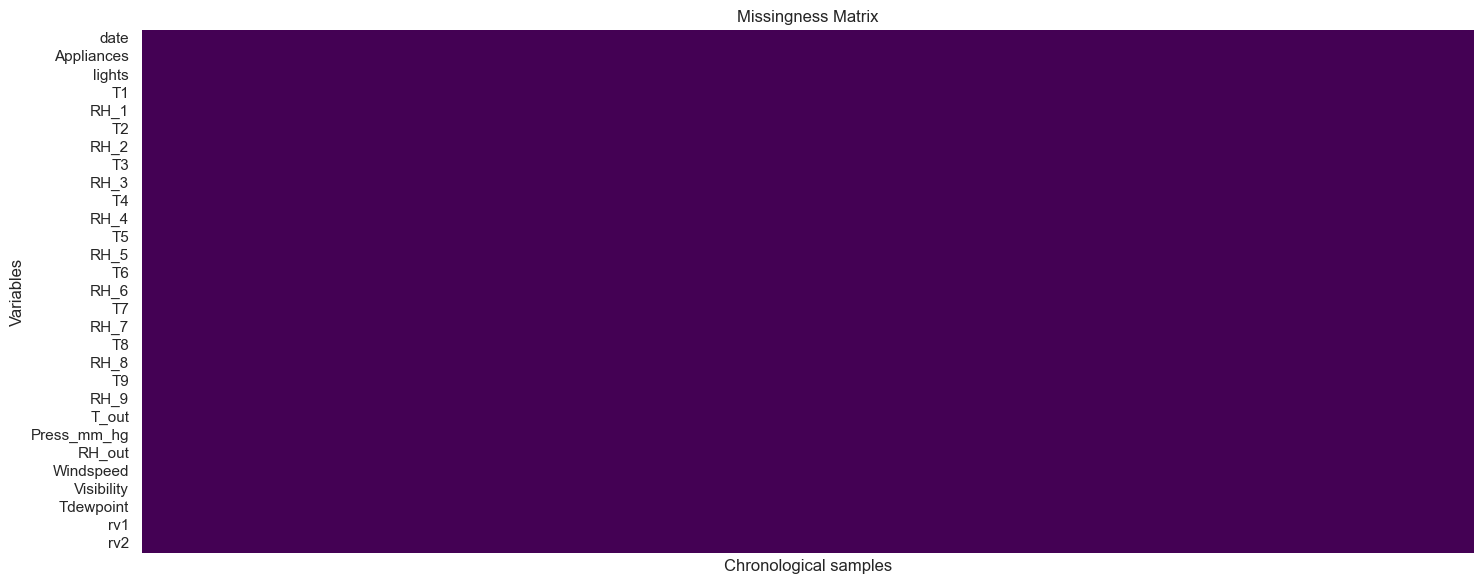

In [10]:
missing_counts = df.isna().sum()
missing_percentage = missing_counts.div(len(df)).mul(100)
missing_df = pd.DataFrame({"Total Missing": missing_counts, "Percentage (%)": missing_percentage})
missing_only = missing_df.loc[missing_df["Total Missing"].gt(0)]
display(missing_df)
display(missing_only if not missing_only.empty else pd.DataFrame({"Result": ["No missing values detected"]}))
figure, axis = plt.subplots(figsize=(15, 6))
sns.heatmap(df.isna().transpose(), cbar=False, cmap="viridis", yticklabels=True, xticklabels=False, ax=axis)
axis.set_title("Missingness Matrix")
axis.set_xlabel("Chronological samples")
axis.set_ylabel("Variables")
figure.tight_layout()
display_figure(figure)

### 6.3 Calendar Derivations and Sampling Coverage

Create EDA-only calendar fields and inspect sample coverage by hour, weekday and weekday/weekend status.

,date,hour,day_of_week,day_name,is_weekend
0,2016-01-11 17:00:00,17,0,Monday,0
1,2016-01-11 17:10:00,17,0,Monday,0
2,2016-01-11 17:20:00,17,0,Monday,0
3,2016-01-11 17:30:00,17,0,Monday,0
4,2016-01-11 17:40:00,17,0,Monday,0


,Sample Count
hour,
0,822
1,822
2,822
3,822
4,822
5,822
6,822
7,822
8,822


,Sample Count
day_name,
Monday,2778
Tuesday,2880
Wednesday,2880
Thursday,2880
Friday,2845
Saturday,2736
Sunday,2736


,Sample Count
is_weekend,
Weekday,14263
Weekend,5472


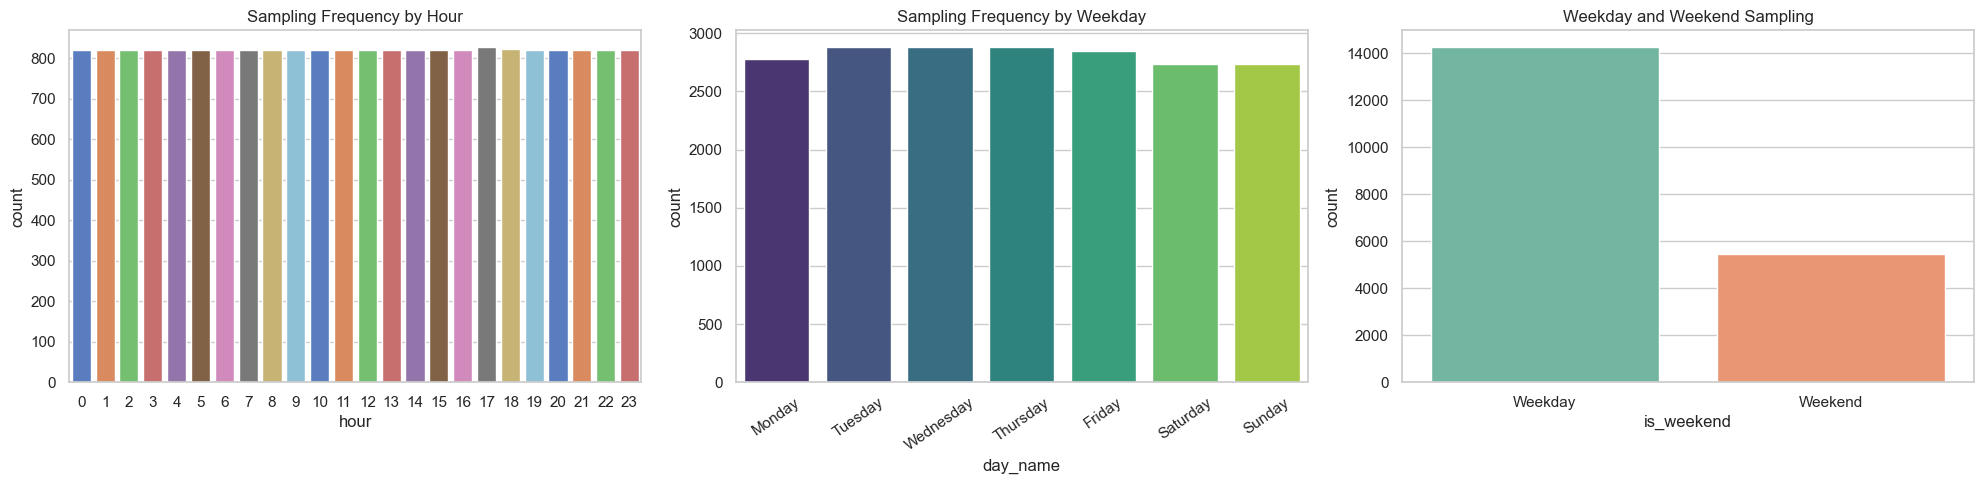

In [11]:
df["hour"] = df["date"].dt.hour
df["day_of_week"] = df["date"].dt.dayofweek
df["day_name"] = df["date"].dt.day_name()
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
hour_counts = df["hour"].value_counts().sort_index()
day_counts = df["day_name"].value_counts().reindex(day_order)
weekend_counts = df["is_weekend"].value_counts().sort_index().rename(index={0: "Weekday", 1: "Weekend"})
display(df[["date", "hour", "day_of_week", "day_name", "is_weekend"]].head())
display(hour_counts.rename("Sample Count").to_frame())
display(day_counts.rename("Sample Count").to_frame())
display(weekend_counts.rename("Sample Count").to_frame())
figure, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.countplot(data=df, x="hour", hue="hour", palette="muted", legend=False, ax=axes[0])
sns.countplot(data=df, x="day_name", order=day_order, hue="day_name", palette="viridis", legend=False, ax=axes[1])
sns.countplot(data=df, x="is_weekend", hue="is_weekend", palette="Set2", legend=False, ax=axes[2])
axes[0].set_title("Sampling Frequency by Hour")
axes[1].set_title("Sampling Frequency by Weekday")
axes[1].tick_params(axis="x", rotation=35)
axes[2].set_title("Weekday and Weekend Sampling")
axes[2].set_xticks([0, 1], ["Weekday", "Weekend"])
figure.tight_layout()
display_figure(figure)

### 6.4 Target Distribution

Inspect target summary, skewness, quantiles, distribution, ECDF, boxplot and high-energy observations using canonical EDA-v1 evidence.

,variable,role,group,count,mean,std,min,q01,q05,q25,median,q75,q90,q95,q99,max,skewness
0,Appliances,target,target,13814,98.775156,106.857292,10.0,20.0,30.0,50.0,60.0,100.0,220.0,340.0,590.0,1080.0,3.249436


,quantile,value_wh
0,0.01,20.0
1,0.05,30.0
2,0.25,50.0
3,0.50,60.0
4,0.75,100.0
5,0.90,220.0
6,0.95,340.0
7,0.99,590.0


,Target,Skewness
0,Appliances,3.386367


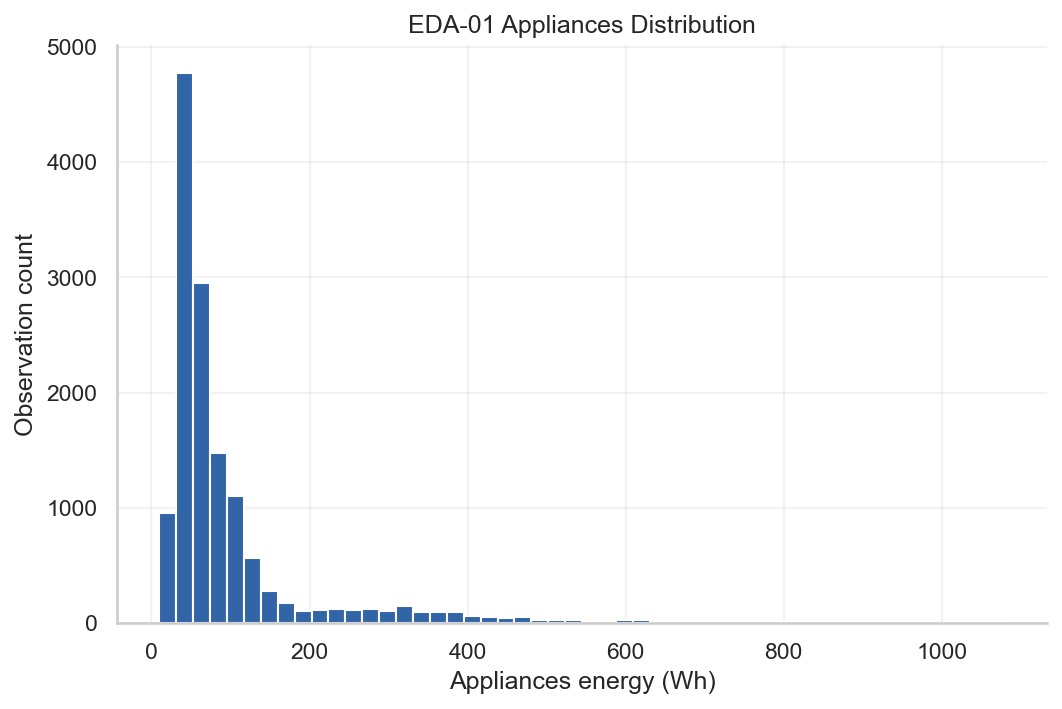

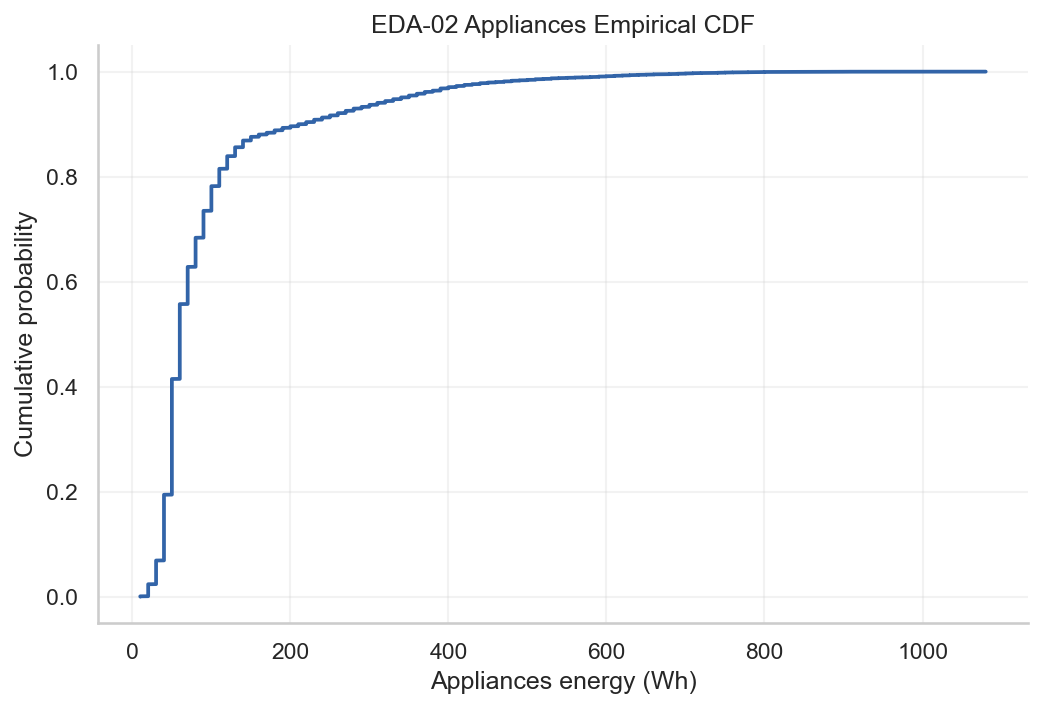

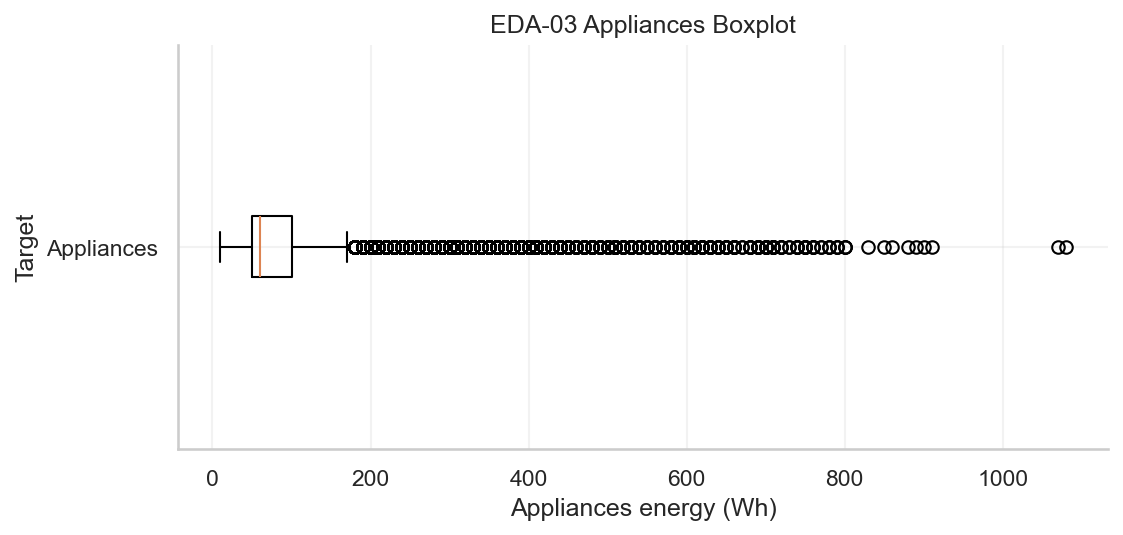

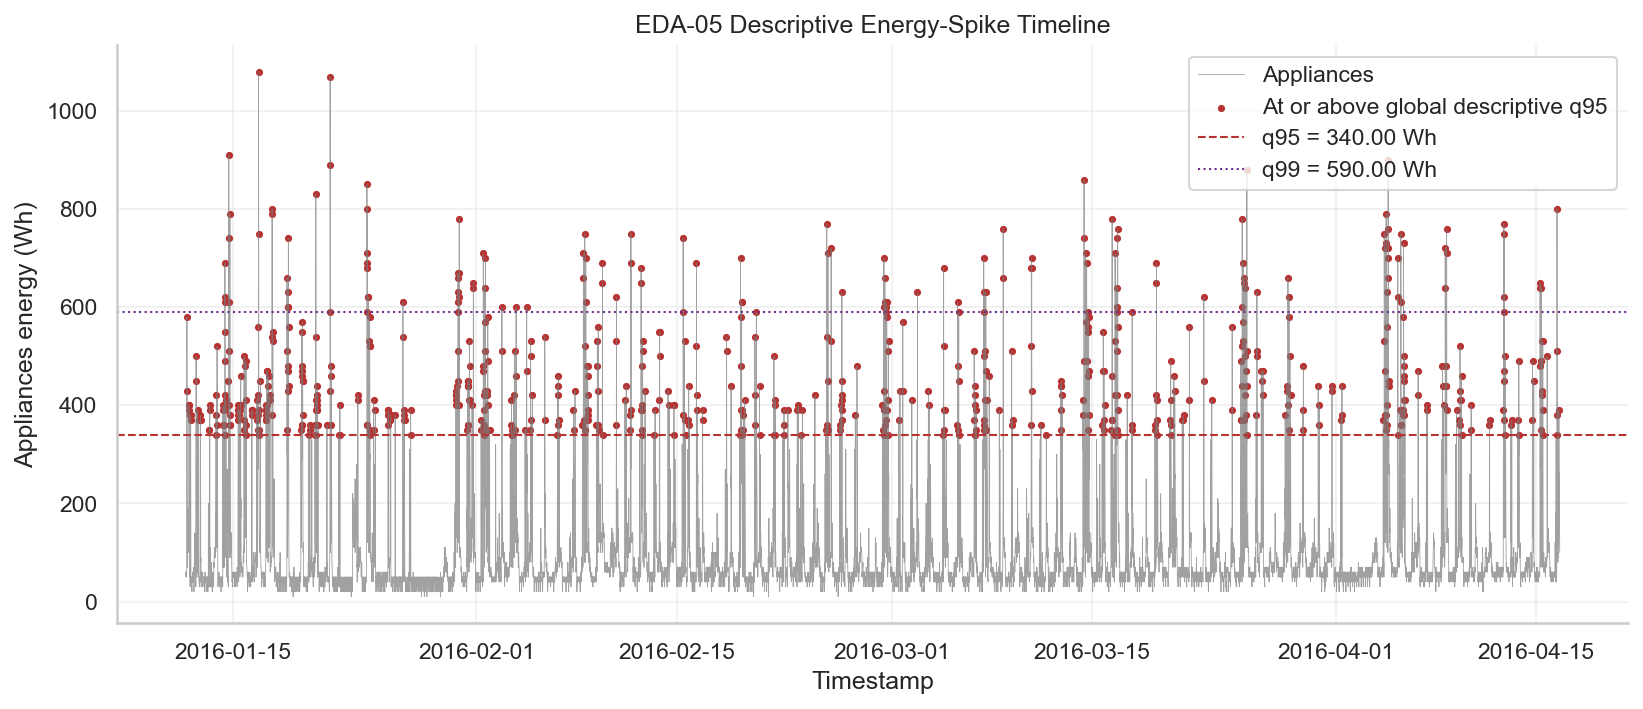

In [12]:
target_summary = pd.read_csv(eda_table_root / "eda_numeric_summary.csv").query("variable == 'Appliances'")
target_quantiles = pd.read_csv(eda_table_root / "target_quantiles.csv")
display(target_summary)
display(target_quantiles)
display(pd.DataFrame({"Target": ["Appliances"], "Skewness": [df["Appliances"].skew()]}))
display(Image(filename=eda_figure_root / "EDA_01_target_histogram.png"))
display(Image(filename=eda_figure_root / "EDA_02_target_ecdf.png"))
display(Image(filename=eda_figure_root / "EDA_03_target_boxplot.png"))
display(Image(filename=eda_figure_root / "EDA_05_energy_spikes.png"))

### 6.5 Target Timeline and Representative Week

Compare the complete target timeline, daily average and the earliest seven-day block.

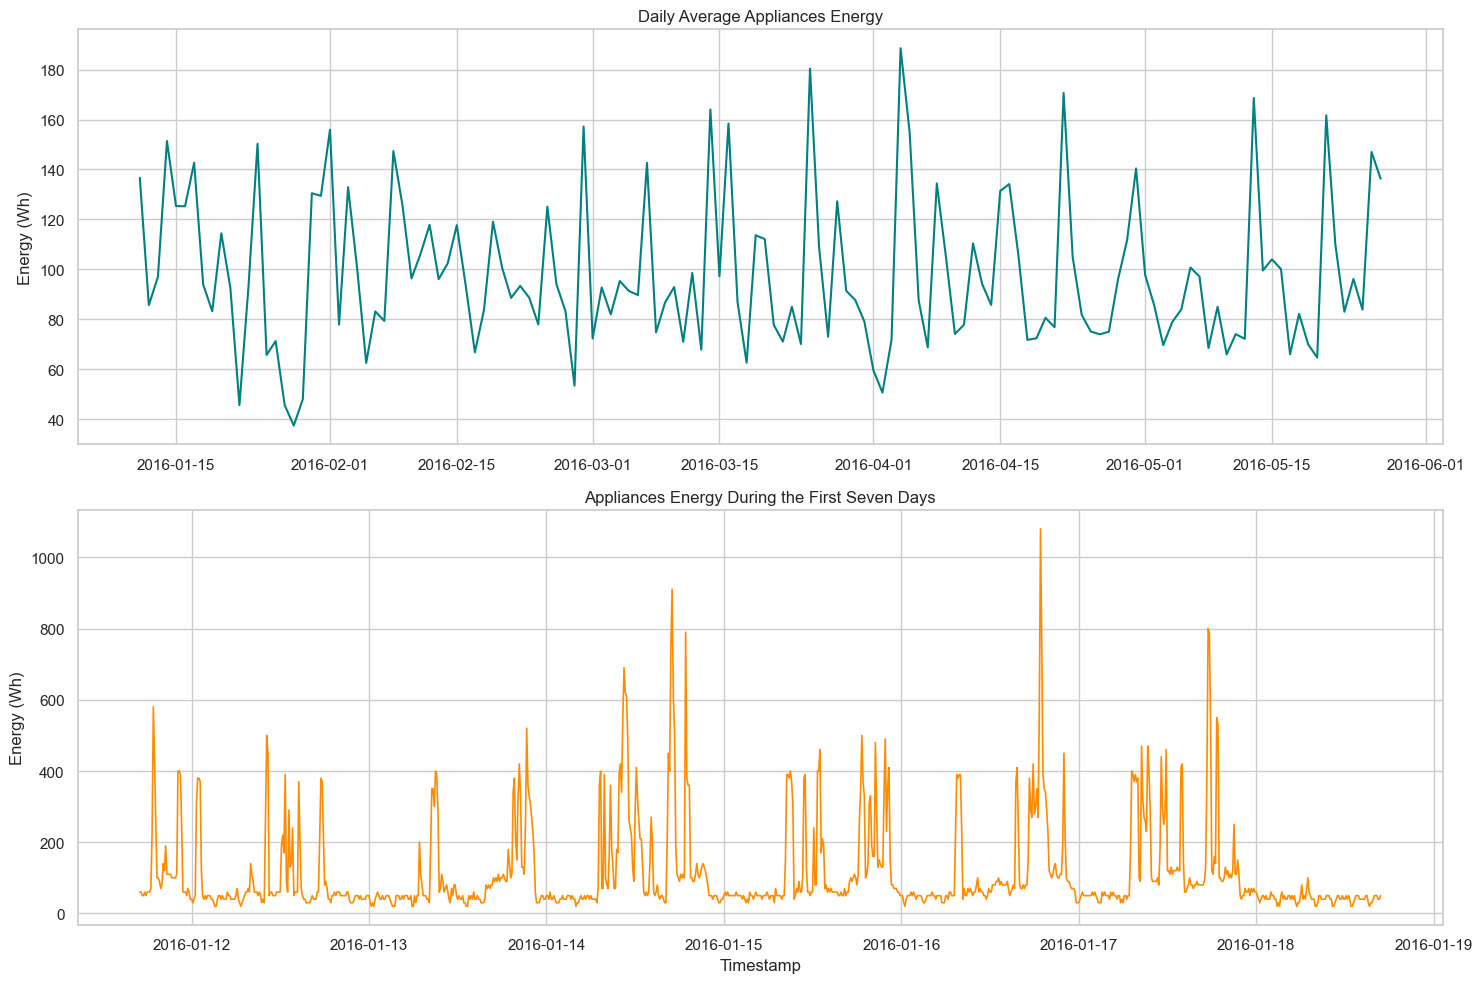

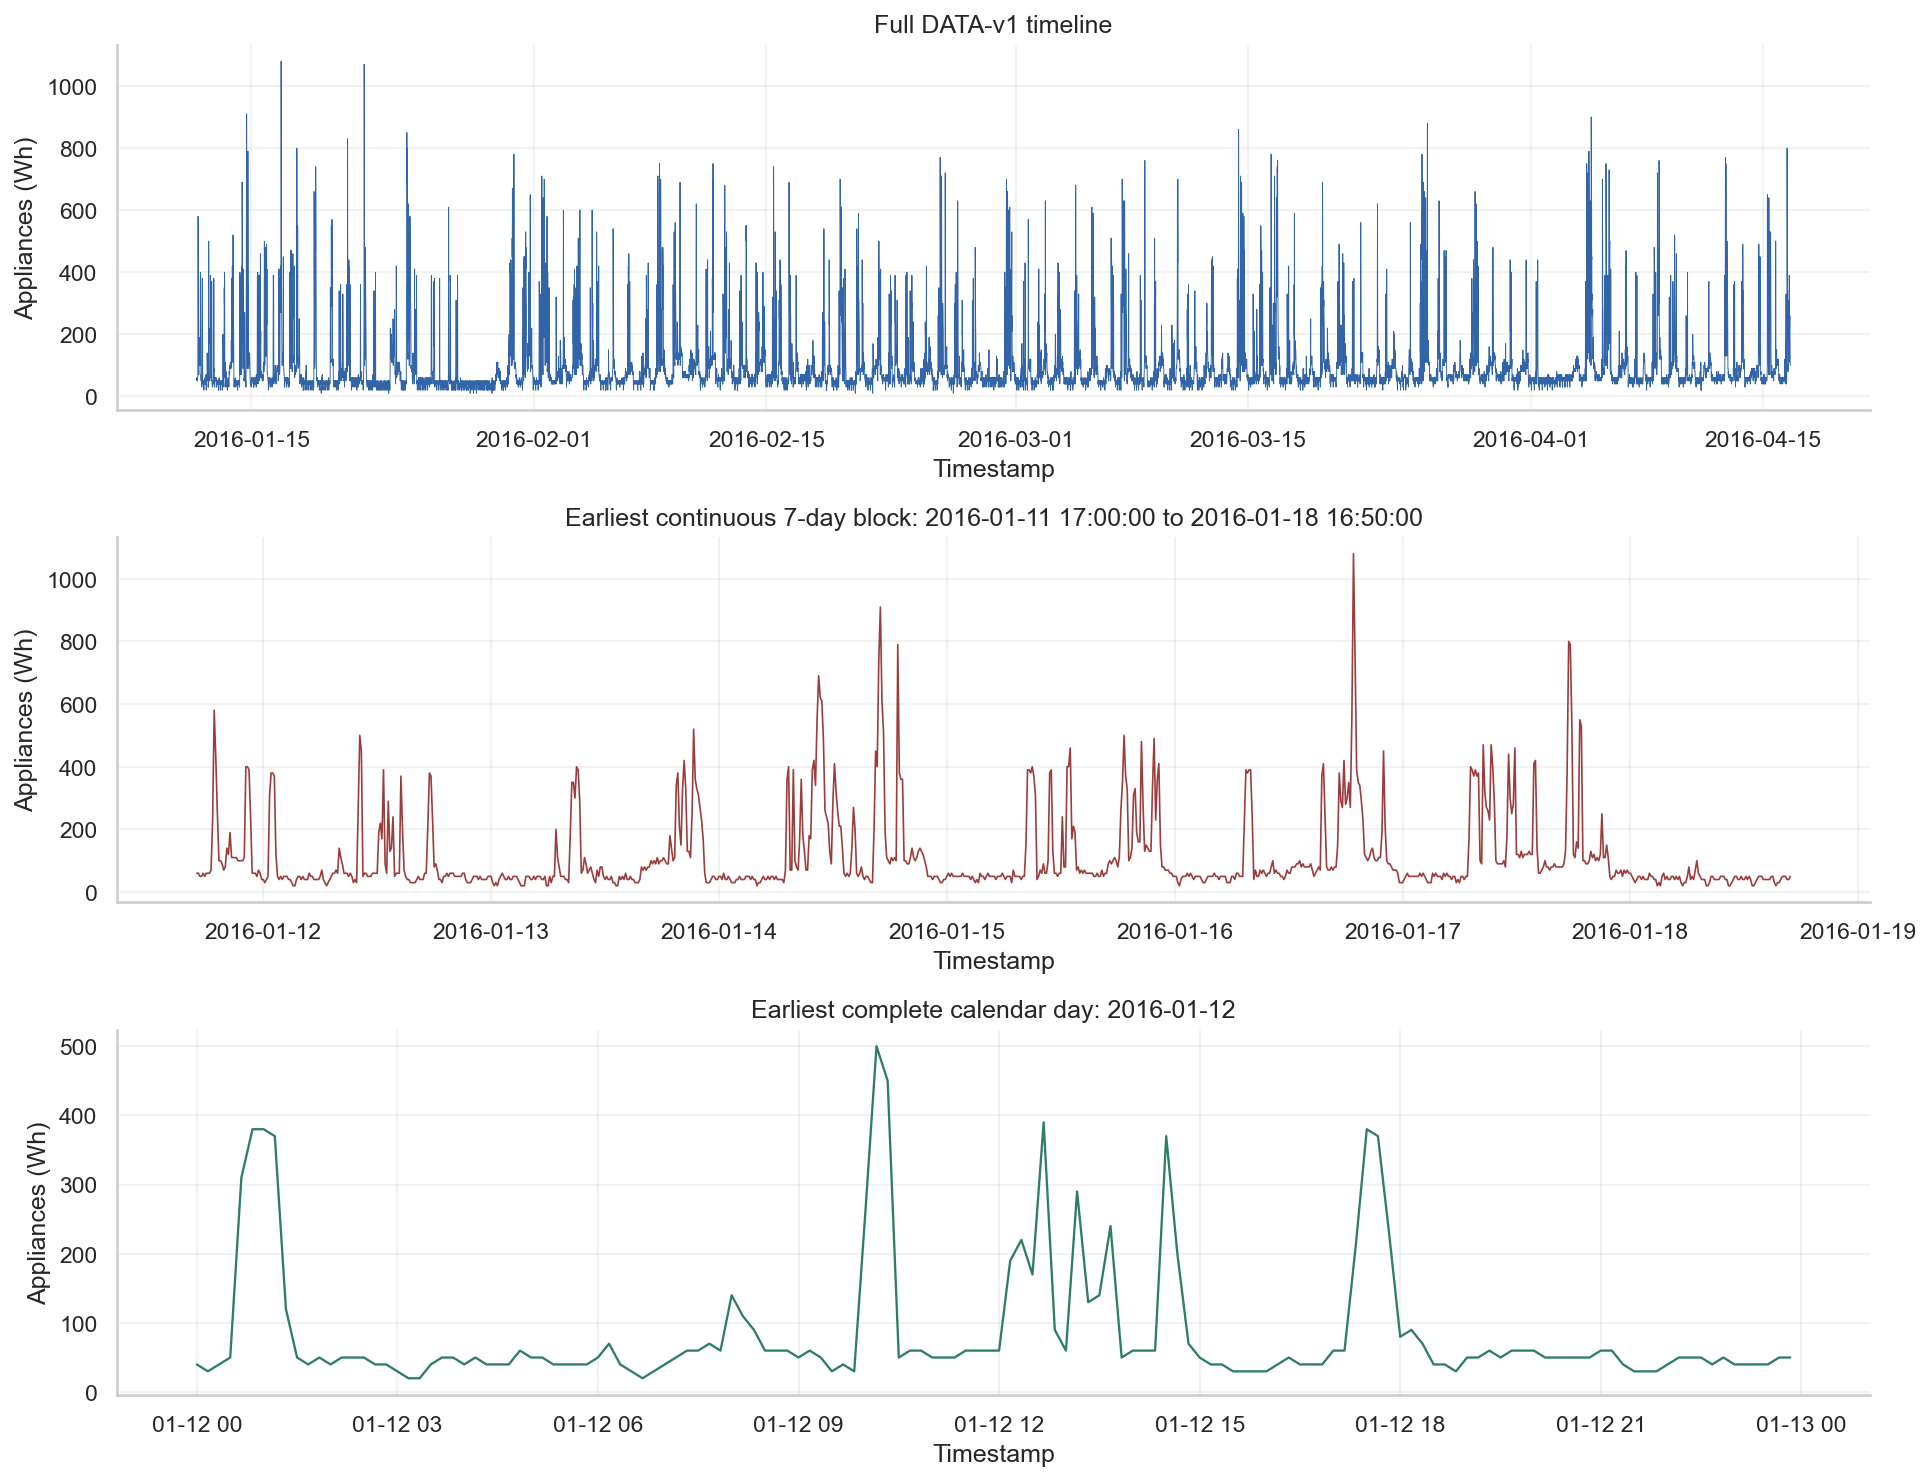

In [13]:
df_time = df.set_index("date")
daily_average = df_time["Appliances"].resample("D").mean()
first_week = df_time.iloc[:1008]
figure, axes = plt.subplots(2, 1, figsize=(15, 10))
axes[0].plot(daily_average.index, daily_average.values, color="teal", linewidth=1.5)
axes[0].set_title("Daily Average Appliances Energy")
axes[0].set_ylabel("Energy (Wh)")
axes[1].plot(first_week.index, first_week["Appliances"], color="darkorange", linewidth=1.2)
axes[1].set_title("Appliances Energy During the First Seven Days")
axes[1].set_xlabel("Timestamp")
axes[1].set_ylabel("Energy (Wh)")
figure.tight_layout()
display_figure(figure)
display(Image(filename=eda_figure_root / "EDA_04_target_timeline.png"))

### 6.6 Calendar Energy Patterns

Inspect hourly, weekday, weekday/weekend and hour-by-weekday target profiles.

,hour,count,mean,median,std,q25,q75
0,0,576,52.447917,50.0,30.027478,40.0,60.0
1,1,576,50.208333,50.0,22.176172,40.0,60.0
2,2,576,47.500000,50.0,10.858777,40.0,50.0
3,3,576,46.579861,50.0,11.599275,40.0,50.0
4,4,576,47.708333,50.0,10.679114,40.0,50.0
5,5,576,48.072917,50.0,18.526641,40.0,50.0
6,6,576,54.357639,50.0,50.195484,40.0,60.0
7,7,576,70.538194,50.0,71.589812,40.0,60.0
8,8,576,104.878472,60.0,115.282575,50.0,90.0
9,9,576,113.559028,70.0,114.192850,50.0,110.0


,day_of_week,day_name,count,mean,median,std,q25,q75
0,0,Monday,1914,124.080460,60.0,137.758988,50.0,120.0
1,1,Tuesday,2016,92.723214,60.0,101.510550,50.0,90.0
2,2,Wednesday,2016,94.553571,70.0,89.496519,50.0,100.0
3,3,Thursday,2016,90.188492,60.0,100.069773,50.0,90.0
4,4,Friday,2016,96.254960,50.0,110.928911,40.0,90.0
5,5,Saturday,1964,99.648676,60.0,103.464829,50.0,100.0
6,6,Sunday,1872,95.010684,60.0,95.334231,50.0,100.0


,is_weekend,day_type,count,mean,median,std,q25,q75
0,False,Weekday,9978,99.309481,60.0,109.521608,50.0,100.0
1,True,Weekend,3836,97.385297,60.0,99.594058,50.0,100.0


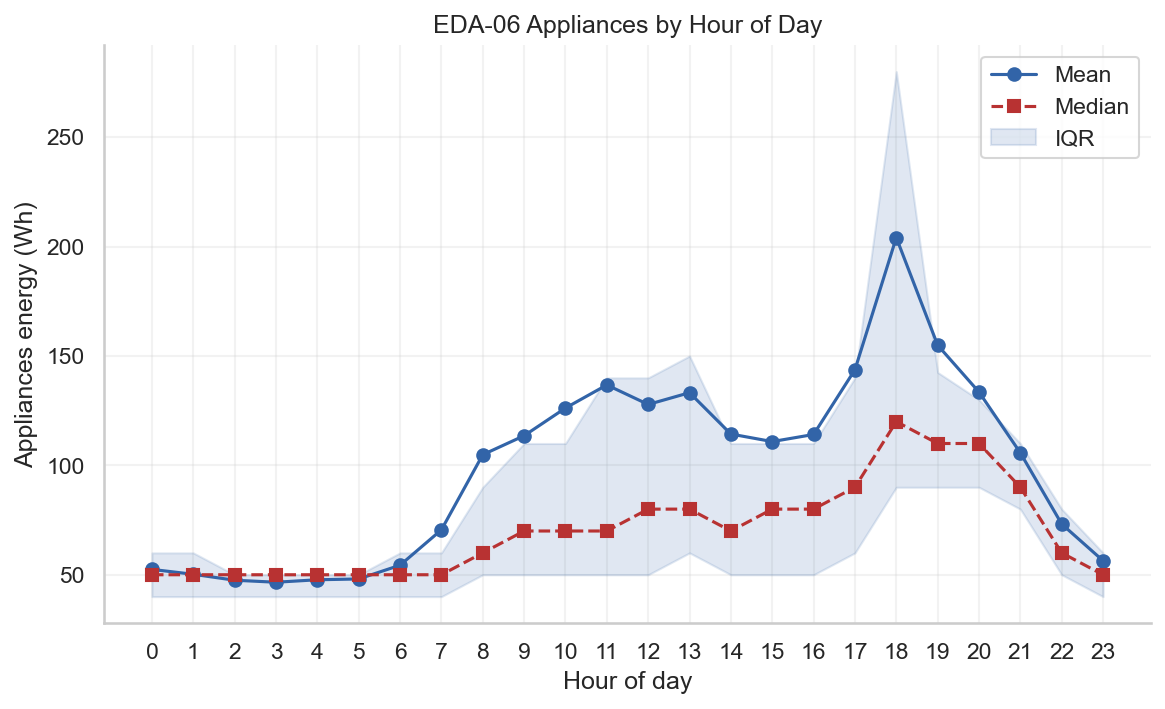

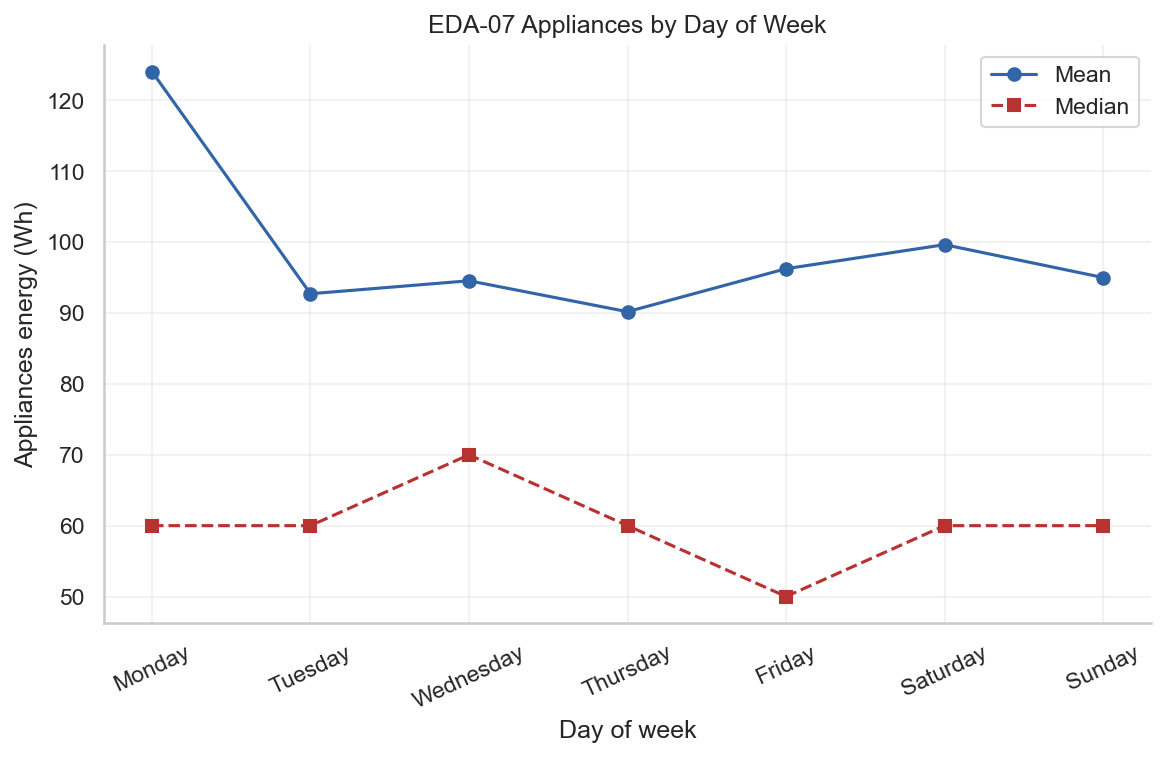

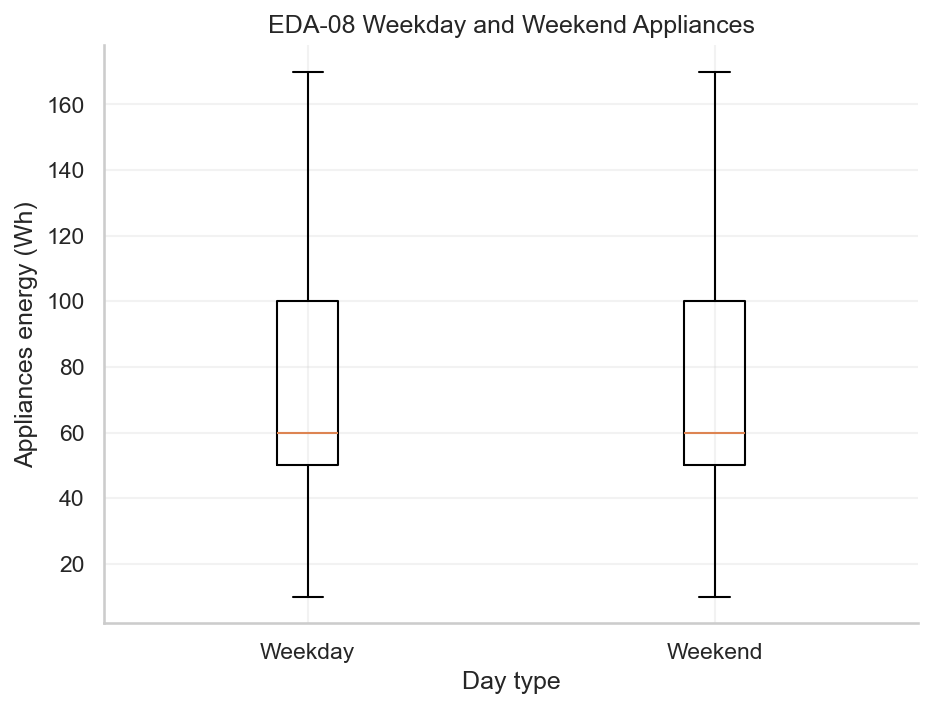

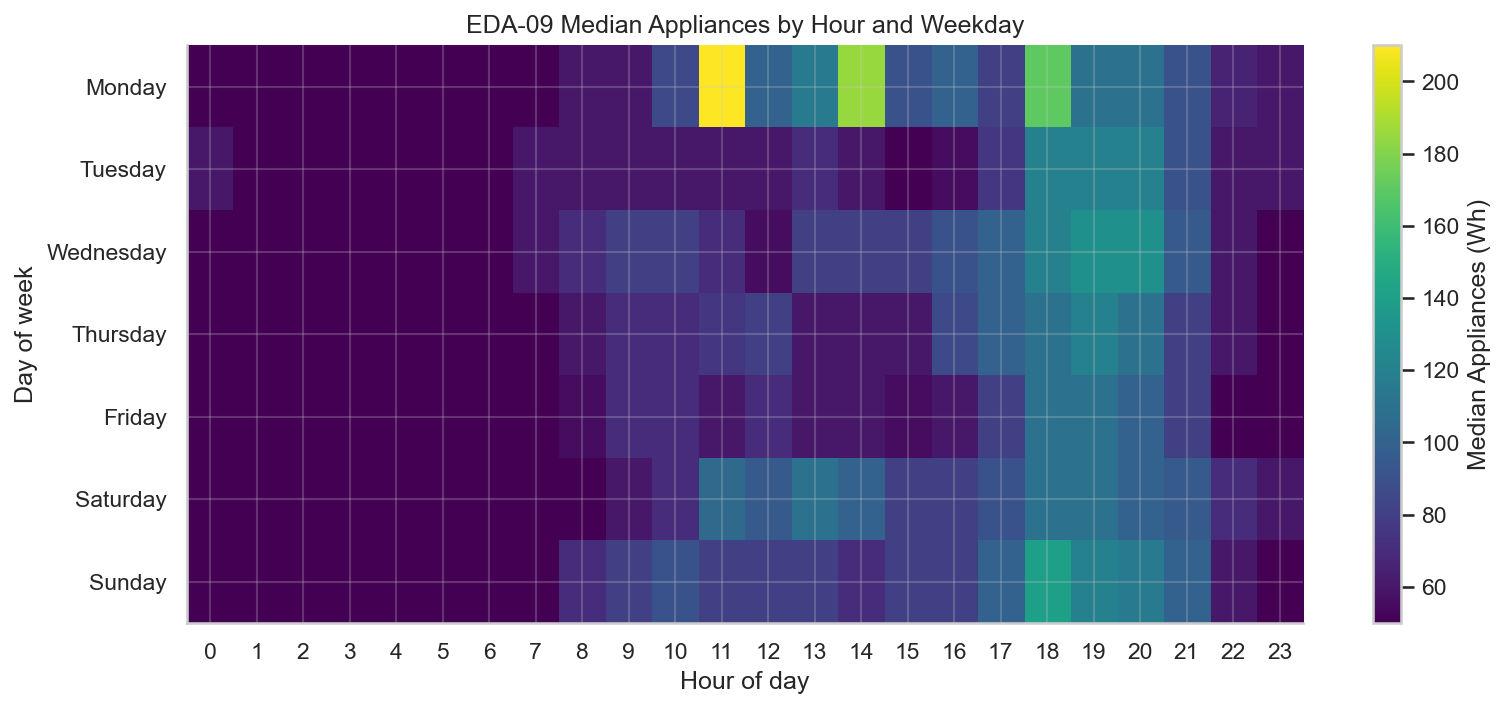

In [14]:
display(pd.read_csv(eda_table_root / "hourly_energy_profile.csv"))
display(pd.read_csv(eda_table_root / "weekday_energy_profile.csv"))
display(pd.read_csv(eda_table_root / "weekend_energy_profile.csv"))
display(Image(filename=eda_figure_root / "EDA_06_hourly_profile.png"))
display(Image(filename=eda_figure_root / "EDA_07_weekday_profile.png"))
display(Image(filename=eda_figure_root / "EDA_08_weekday_weekend.png"))
display(Image(filename=eda_figure_root / "EDA_09_hour_weekday_heatmap.png"))

### 6.7 Feature Distributions

Inspect temperature, humidity and lighting groups without selecting or removing features.

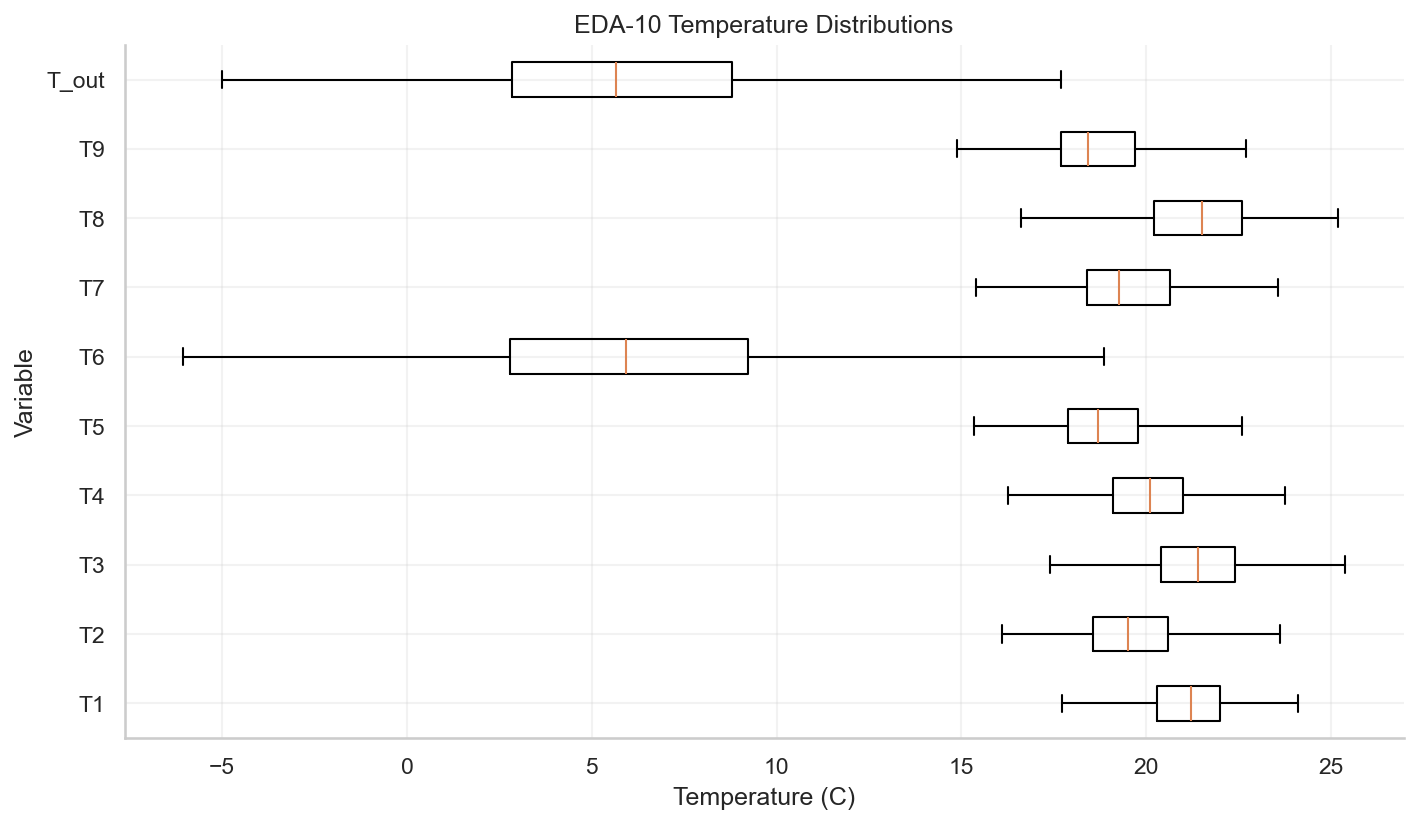

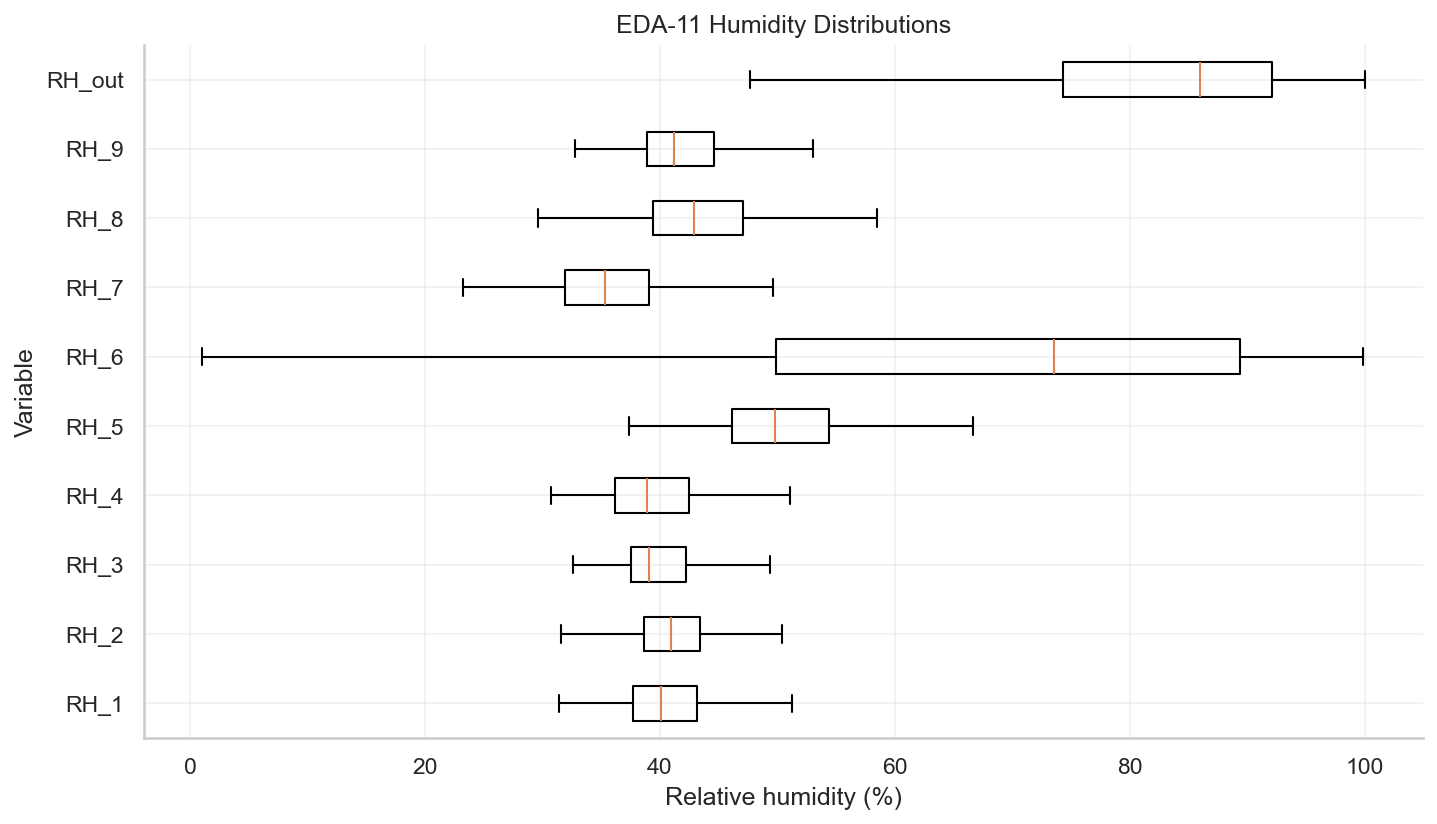

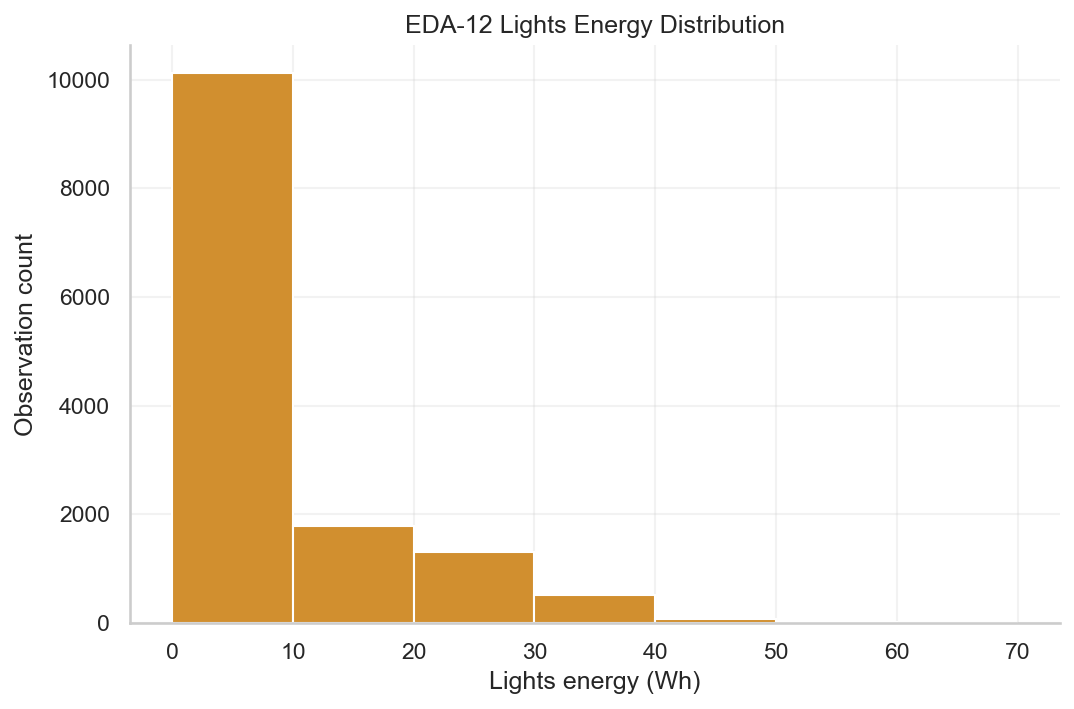

In [15]:
display(Image(filename=eda_figure_root / "EDA_10_temperature_distributions.png"))
display(Image(filename=eda_figure_root / "EDA_11_humidity_distributions.png"))
display(Image(filename=eda_figure_root / "EDA_12_lights_distribution.png"))

### 6.8 Numerical Relationships

Review the canonical correlation matrix, rank target associations and inspect the two strongest instantaneous relationships.

,Absolute Pearson Correlation
lights,0.197278
RH_out,0.152282
T2,0.120073
T6,0.117638
T_out,0.099155


,feature_1,feature_2,pearson_r,absolute_pearson_r,threshold,threshold_purpose
0,rv1,rv2,1.000000,1.000000,0.8,descriptive_flag_not_feature_removal
1,T6,T_out,0.973871,0.973871,0.8,descriptive_flag_not_feature_removal
2,RH_4,RH_7,0.899480,0.899480,0.8,descriptive_flag_not_feature_removal
3,RH_3,RH_4,0.898054,0.898054,0.8,descriptive_flag_not_feature_removal
4,RH_7,RH_8,0.880703,0.880703,0.8,descriptive_flag_not_feature_removal
5,T7,T9,0.880619,0.880619,0.8,descriptive_flag_not_feature_removal
6,RH_1,RH_4,0.860672,0.860672,0.8,descriptive_flag_not_feature_removal
7,RH_8,RH_9,0.851155,0.851155,0.8,descriptive_flag_not_feature_removal
8,RH_4,RH_9,0.848194,0.848194,0.8,descriptive_flag_not_feature_removal
9,RH_7,RH_9,0.847945,0.847945,0.8,descriptive_flag_not_feature_removal


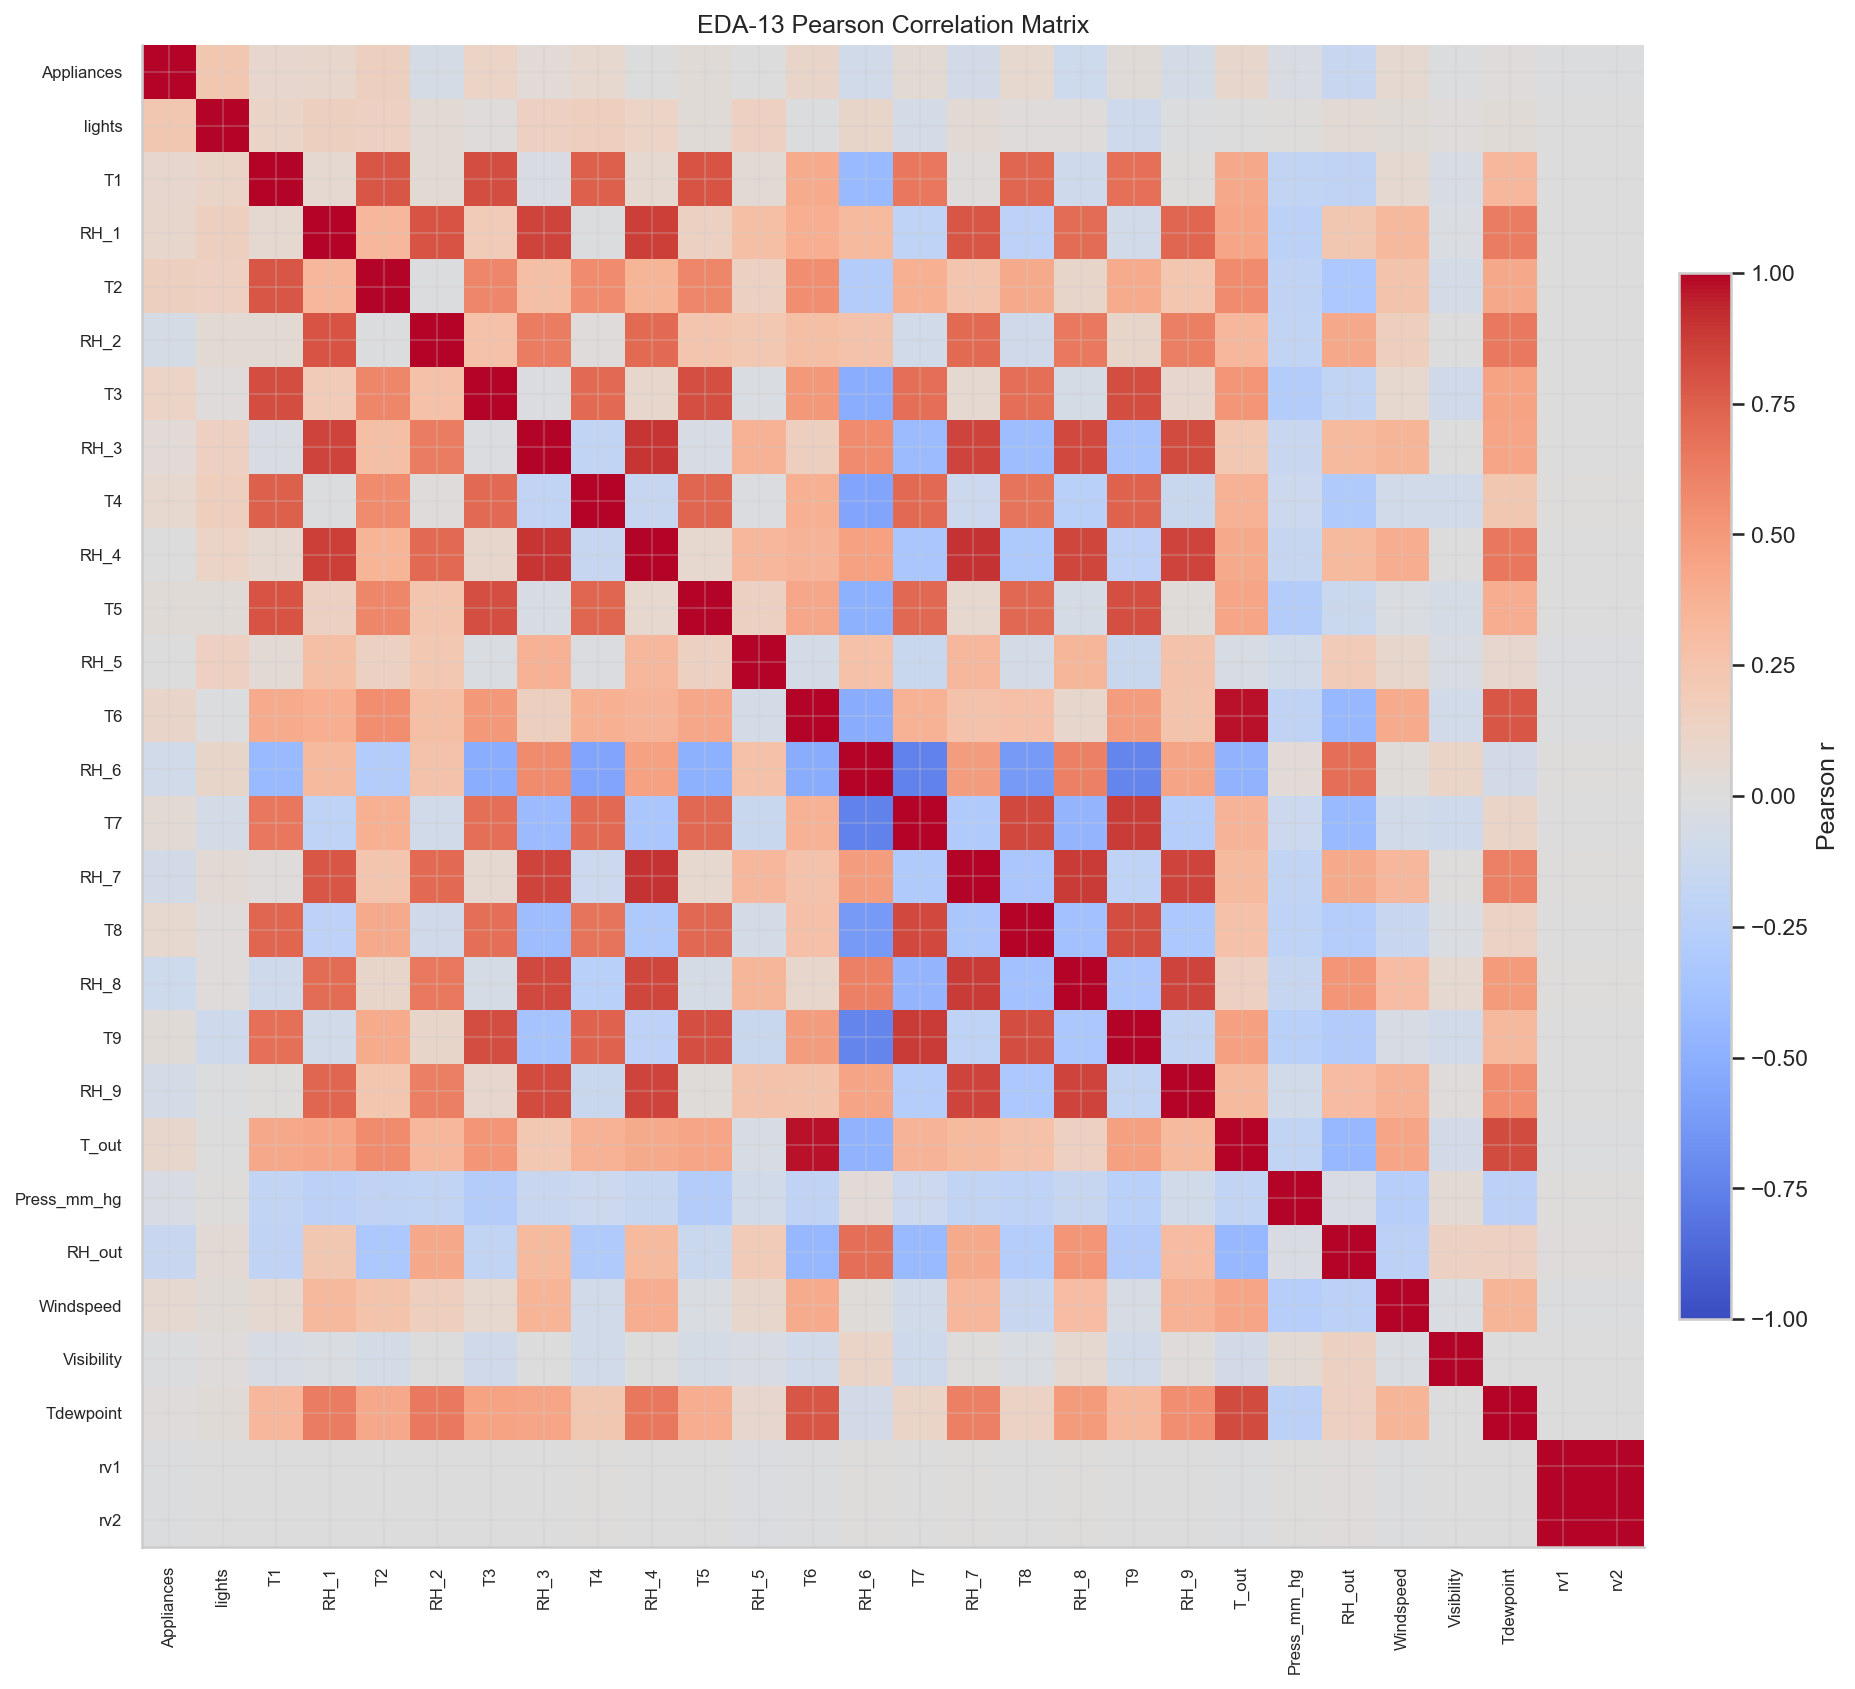

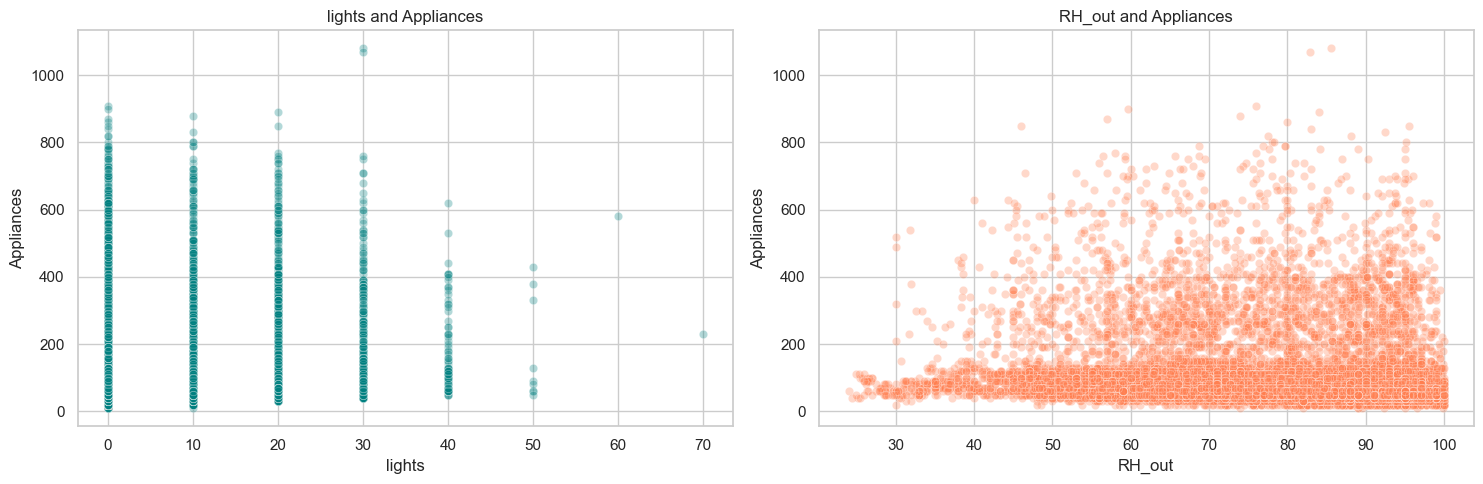

In [16]:
sensor_columns = [column for column in phase_6_schema["ordered_columns"] if column != "date"]
correlation_matrix = df[sensor_columns].corr(method="pearson")
top_correlations = correlation_matrix["Appliances"].drop("Appliances").abs().sort_values(ascending=False).head(5)
top_feature = top_correlations.index[0]
second_top_feature = top_correlations.index[1]
display(top_correlations.rename("Absolute Pearson Correlation").to_frame())
display(pd.read_csv(eda_table_root / "high_correlation_pairs.csv").head(20))
display(Image(filename=eda_figure_root / "EDA_13_correlation_heatmap.png"))
figure, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=df, x=top_feature, y="Appliances", alpha=0.3, color="teal", ax=axes[0])
sns.scatterplot(data=df, x=second_top_feature, y="Appliances", alpha=0.3, color="coral", ax=axes[1])
axes[0].set_title(f"{top_feature} and Appliances")
axes[1].set_title(f"{second_top_feature} and Appliances")
figure.tight_layout()
display_figure(figure)

### 6.9 Cross-Correlation at Short Lags

Calculate a descriptive ±24-step profile for the strongest instantaneous feature while preserving continuity-segment boundaries.

,lag_steps,lag_minutes,correlation,valid_pair_count
0,-24,-240,0.110158,19711
1,-23,-230,0.112075,19712
2,-22,-220,0.123032,19713
3,-21,-210,0.132557,19714
4,-20,-200,0.134243,19715
5,-19,-190,0.133568,19716
6,-18,-180,0.138862,19717
7,-17,-170,0.141943,19718
8,-16,-160,0.151385,19719
9,-15,-150,0.158109,19720


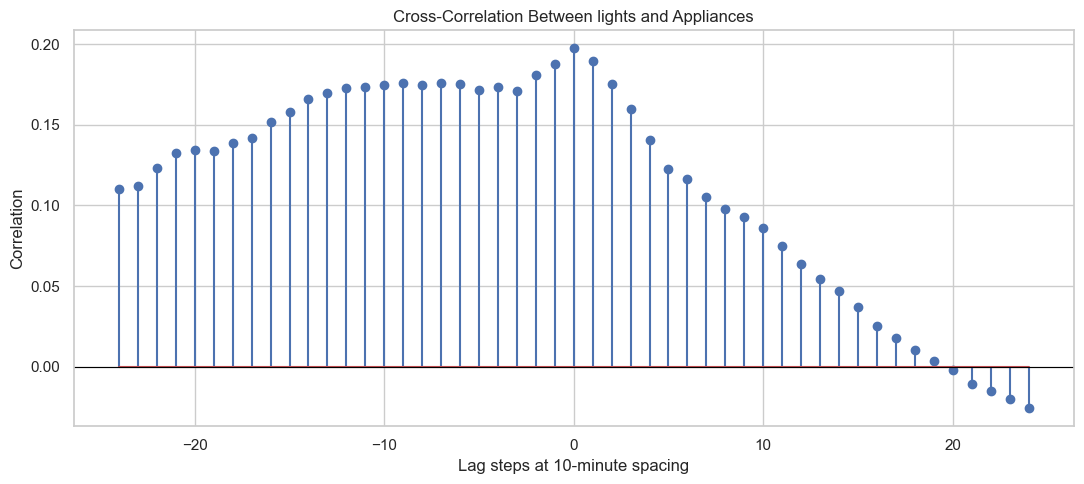

In [17]:
def calculate_segment_cross_correlation(dataframe, feature, target, maximum_lag):
    rows = []
    for lag in range(-maximum_lag, maximum_lag + 1):
        feature_parts = []
        target_parts = []
        for _, segment in dataframe.groupby("continuity_segment_id", sort=False):
            paired = pd.concat([segment[feature], segment[target].shift(-lag)], axis=1).dropna()
            feature_parts.append(paired.iloc[:, 0])
            target_parts.append(paired.iloc[:, 1])
        feature_values = pd.concat(feature_parts, ignore_index=True)
        target_values = pd.concat(target_parts, ignore_index=True)
        rows.append({"lag_steps": lag, "lag_minutes": lag * 10, "correlation": feature_values.corr(target_values), "valid_pair_count": len(feature_values)})
    return pd.DataFrame(rows)

cross_correlation_profile = calculate_segment_cross_correlation(eda_temporal_view, top_feature, "Appliances", 24)
display(cross_correlation_profile)
figure, axis = plt.subplots(figsize=(11, 5))
axis.stem(cross_correlation_profile["lag_steps"], cross_correlation_profile["correlation"])
axis.axhline(0, color="black", linewidth=0.8)
axis.set_title(f"Cross-Correlation Between {top_feature} and Appliances")
axis.set_xlabel("Lag steps at 10-minute spacing")
axis.set_ylabel("Correlation")
figure.tight_layout()
display_figure(figure)

### 6.10 Categorical and Numerical Relationships

Compare target distributions by weekday/weekend status and hour without treating global observations as model-selection evidence.

,count,mean,std,min,25%,50%,75%,max
is_weekend,,,,,,,,
Weekday,14263.0,96.587674,103.086372,10.0,50.0,60.0,90.0,1070.0
Weekend,5472.0,100.581140,100.998987,10.0,50.0,70.0,100.0,1080.0


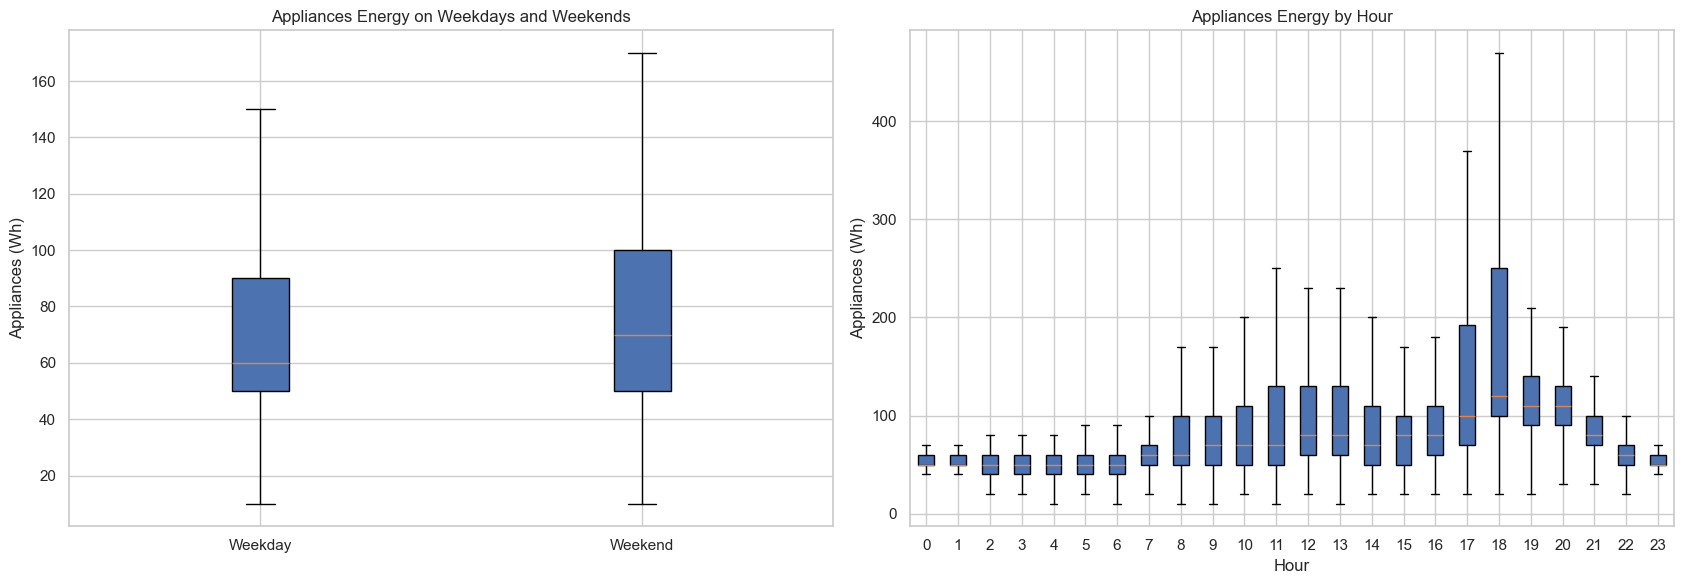

In [18]:
display(df.groupby("is_weekend")["Appliances"].describe().rename(index={0: "Weekday", 1: "Weekend"}))
weekend_groups = [df.loc[df["is_weekend"].eq(value), "Appliances"].to_numpy() for value in [0, 1]]
hour_groups = [df.loc[df["hour"].eq(hour), "Appliances"].to_numpy() for hour in range(24)]
figure, axes = plt.subplots(1, 2, figsize=(17, 6))
axes[0].boxplot(weekend_groups, tick_labels=["Weekday", "Weekend"], showfliers=False, patch_artist=True, orientation="vertical")
axes[1].boxplot(hour_groups, tick_labels=list(range(24)), showfliers=False, patch_artist=True, orientation="vertical")
axes[0].set_title("Appliances Energy on Weekdays and Weekends")
axes[1].set_title("Appliances Energy by Hour")
axes[0].set_ylabel("Appliances (Wh)")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Appliances (Wh)")
figure.tight_layout()
display_figure(figure)

### 6.11 Descriptive IQR Outlier Diagnostics

Count IQR flags for sensor variables without authorizing row removal, clipping or canonical imputation.

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Percentage (%)
0,Visibility,29.000000,40.000000,11.000000,12.500000,56.500000,2522,12.779326
1,RH_5,45.400000,53.663333,8.263333,33.005000,66.058333,1330,6.739296
2,T2,18.790000,21.500000,2.710000,14.725000,25.565000,546,2.766658
3,T6,3.626667,11.256000,7.629333,-7.817333,22.700000,515,2.609577
4,T1,20.760000,22.600000,1.840000,18.000000,25.360000,515,2.609577
5,T_out,3.666667,10.408333,6.741667,-6.445833,20.520833,436,2.209273
6,RH_out,70.333333,91.666667,21.333333,38.333333,123.666667,239,1.211046
7,RH_2,37.900000,43.260000,5.360000,29.860000,51.300000,235,1.190778
8,Press_mm_hg,750.933333,760.933333,10.000000,735.933333,775.933333,219,1.109704
9,T3,20.790000,23.290000,2.500000,17.040000,27.040000,217,1.099569


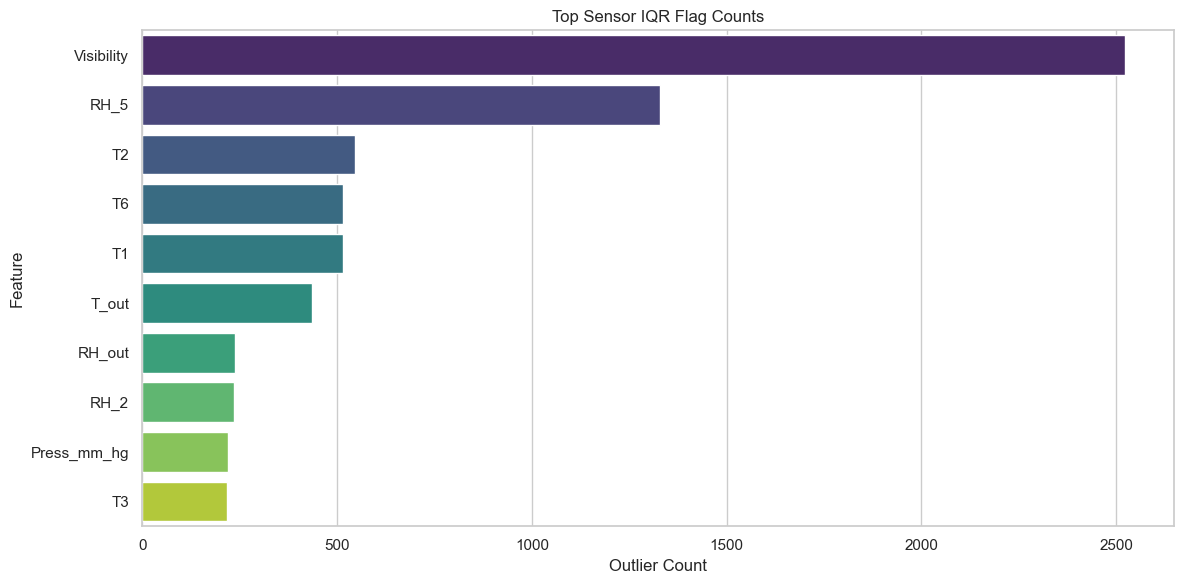

In [19]:
def summarize_iqr_outliers(dataframe, columns):
    rows = []
    for column in columns:
        first_quartile = dataframe[column].quantile(0.25)
        third_quartile = dataframe[column].quantile(0.75)
        interquartile_range = third_quartile - first_quartile
        lower_bound = first_quartile - 1.5 * interquartile_range
        upper_bound = third_quartile + 1.5 * interquartile_range
        outlier_mask = dataframe[column].lt(lower_bound) | dataframe[column].gt(upper_bound)
        rows.append({"Feature": column, "Q1": first_quartile, "Q3": third_quartile, "IQR": interquartile_range, "Lower Bound": lower_bound, "Upper Bound": upper_bound, "Outlier Count": int(outlier_mask.sum()), "Percentage (%)": float(outlier_mask.mean() * 100)})
    return pd.DataFrame(rows).sort_values("Outlier Count", ascending=False).reset_index(drop=True)

iqr_sensor_columns = [column for column in df.columns if column.startswith("T") or column.startswith("RH") or column in ["Press_mm_hg", "Windspeed", "Visibility", "Tdewpoint"]]
outlier_summary = summarize_iqr_outliers(df, iqr_sensor_columns)
top_outliers = outlier_summary.head(10)
display(top_outliers)
figure, axis = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_outliers, x="Outlier Count", y="Feature", hue="Feature", palette="viridis", legend=False, ax=axis)
axis.set_title("Top Sensor IQR Flag Counts")
figure.tight_layout()
display_figure(figure)

### 6.12 Isolated Outlier-Smoothing Demonstration

Reproduce the reference notebook's before/after visualization on a deep copy only. The smoothed copy is not saved, signed, handed to Phase 6 or used by any model.

,Canonical DataFrame Unchanged,Demonstration Feature,Pipeline Usage
0,True,Visibility,Forbidden


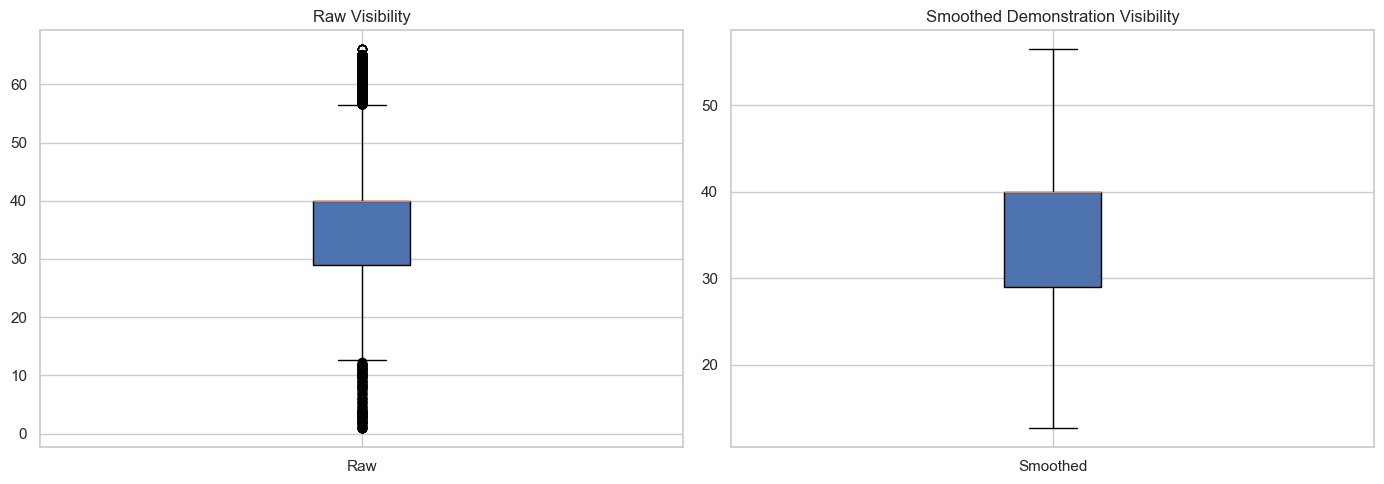

In [20]:
df_before_smoothing = df.copy(deep=True)
df_eda_smoothed_demo = df.copy(deep=True)
for column in iqr_sensor_columns:
    bounds = outlier_summary.set_index("Feature").loc[column]
    outlier_mask = df_eda_smoothed_demo[column].lt(bounds["Lower Bound"]) | df_eda_smoothed_demo[column].gt(bounds["Upper Bound"])
    df_eda_smoothed_demo.loc[outlier_mask, column] = np.nan
    df_eda_smoothed_demo[column] = df_eda_smoothed_demo[column].interpolate(method="linear", limit_direction="both")
top_outlier_feature = outlier_summary.iloc[0]["Feature"]
display(pd.DataFrame({"Canonical DataFrame Unchanged": [df.equals(df_before_smoothing)], "Demonstration Feature": [top_outlier_feature], "Pipeline Usage": ["Forbidden"]}))
figure, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot([df[top_outlier_feature].dropna().to_numpy()], tick_labels=["Raw"], patch_artist=True, orientation="vertical")
axes[1].boxplot([df_eda_smoothed_demo[top_outlier_feature].dropna().to_numpy()], tick_labels=["Smoothed"], patch_artist=True, orientation="vertical")
axes[0].set_title(f"Raw {top_outlier_feature}")
axes[1].set_title(f"Smoothed Demonstration {top_outlier_feature}")
figure.tight_layout()
display_figure(figure)

### 6.13 Time-Series Diagnostics

Review segment-aware autocorrelation, registered exogenous lags and rolling statistics from EDA-v1.

,lag_steps,lag_minutes,lag_label,correlation,valid_pair_count,decision_status
0,1,10,10 min,0.758802,13813,DESCRIPTIVE_NOT_LOOKBACK_SELECTION
1,6,60,1 h,0.324557,13808,DESCRIPTIVE_NOT_LOOKBACK_SELECTION
2,36,360,6 h,0.011009,13778,DESCRIPTIVE_NOT_LOOKBACK_SELECTION
3,72,720,12 h,-0.107492,13742,DESCRIPTIVE_NOT_LOOKBACK_SELECTION
4,144,1440,24 h,0.208330,13670,DESCRIPTIVE_NOT_LOOKBACK_SELECTION
5,1008,10080,7 d,0.212591,12806,DESCRIPTIVE_NOT_LOOKBACK_SELECTION


,feature,lag_steps,lag_minutes,correlation_with_future_target,valid_pair_count,decision_status
0,lights,1,10,0.216134,13813,HYPOTHESIS_ONLY
1,lights,6,60,0.130196,13808,HYPOTHESIS_ONLY
2,lights,36,360,-0.077088,13778,HYPOTHESIS_ONLY
3,lights,72,720,-0.019892,13742,HYPOTHESIS_ONLY
4,lights,144,1440,0.141864,13670,HYPOTHESIS_ONLY
5,T1,1,10,0.072802,13813,HYPOTHESIS_ONLY
6,T1,6,60,0.026527,13808,HYPOTHESIS_ONLY
7,T1,36,360,-0.106064,13778,HYPOTHESIS_ONLY
8,T1,72,720,-0.012331,13742,HYPOTHESIS_ONLY
9,T1,144,1440,0.035280,13670,HYPOTHESIS_ONLY


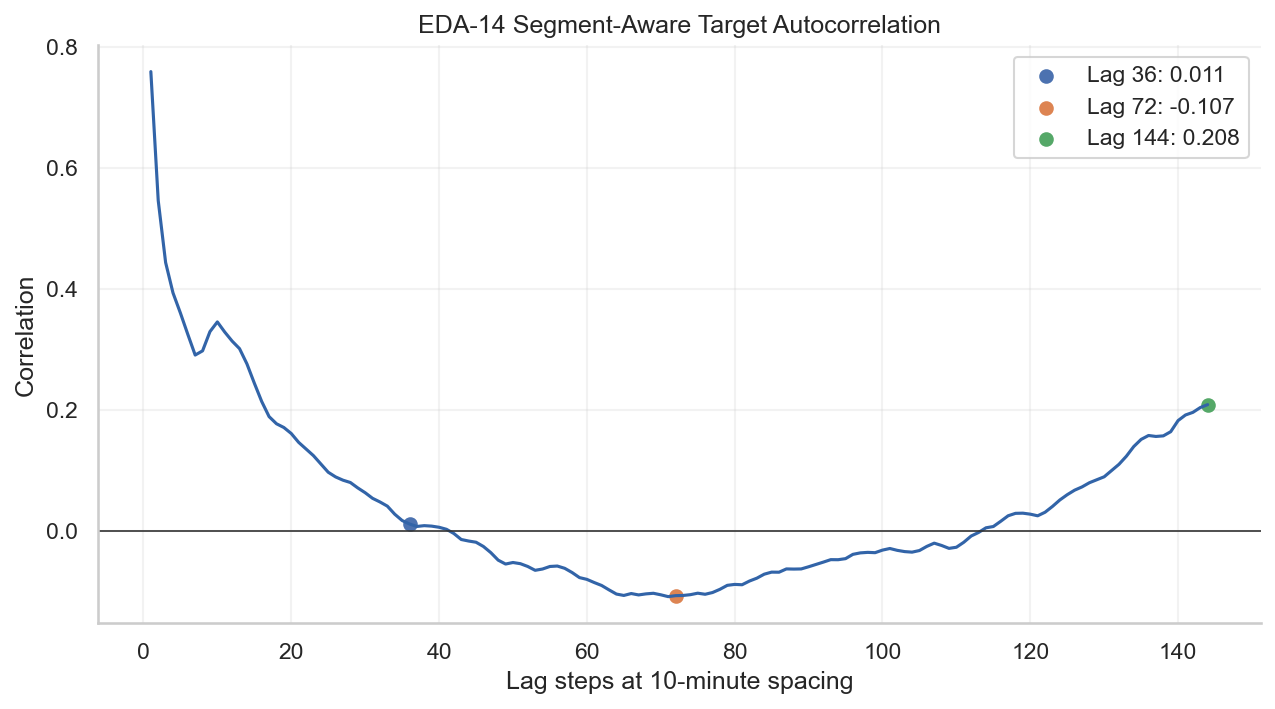

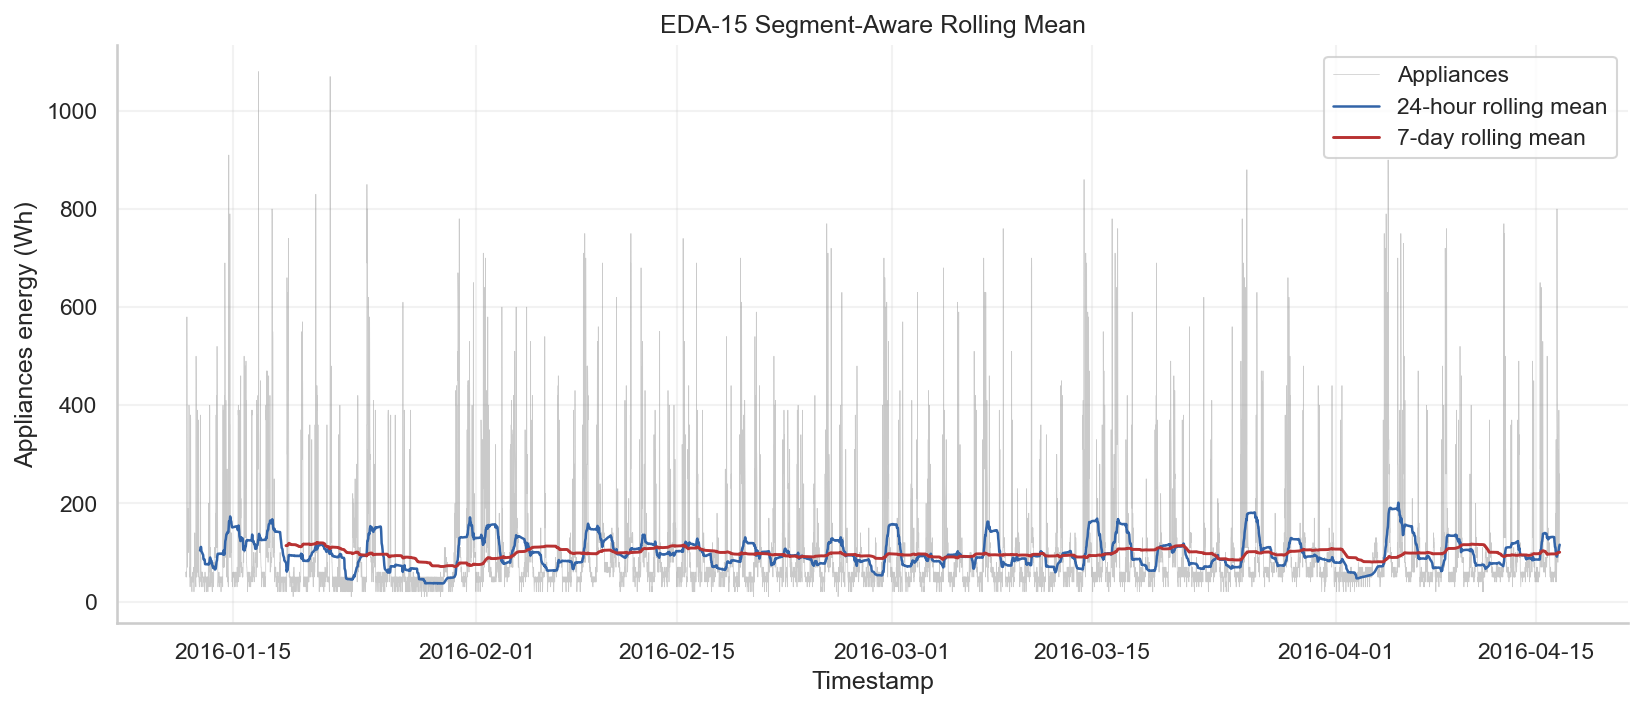

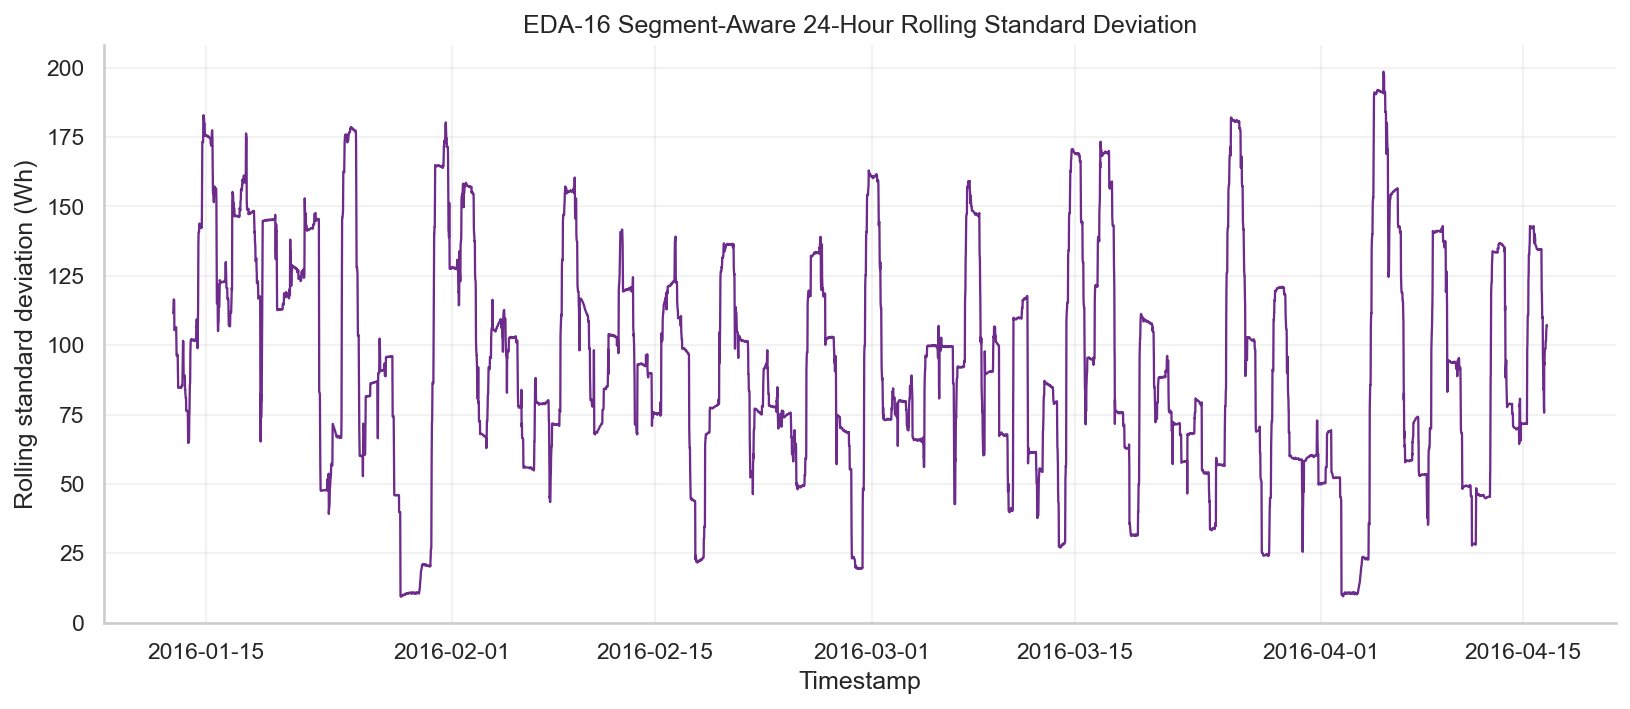

In [21]:
display(pd.read_csv(eda_table_root / "selected_lag_correlations.csv"))
display(pd.read_csv(eda_table_root / "selected_exogenous_lag_correlations.csv"))
display(Image(filename=eda_figure_root / "EDA_14_target_autocorrelation.png"))
display(Image(filename=eda_figure_root / "EDA_15_rolling_mean.png"))
display(Image(filename=eda_figure_root / "EDA_16_rolling_standard_deviation.png"))

### 6.14 Extreme Samples, Hypotheses and Sign-Off

Close Phase 6 with extreme-target samples, explicitly untested hypotheses, anomaly records and the immutable sign-off.

In [22]:
display(pd.read_csv(eda_table_root / "extreme_target_samples.csv"))
display(pd.read_csv(eda_table_root / "eda_hypotheses.csv"))

,raw_row_index,timestamp,continuity_segment_id,Appliances,lights,T1,RH_1,T_out,RH_out,Windspeed,descriptive_only
0,731,2016-01-16 18:50:00,SEG-0001,1080,30,21.930000,42.766667,2.083333,85.500000,3.666667,True
1,1451,2016-01-21 18:50:00,SEG-0001,1070,30,19.600000,34.300000,-0.616667,82.833333,1.000000,True
2,432,2016-01-14 17:00:00,SEG-0001,910,0,21.463333,41.693333,4.600000,76.000000,7.000000,True
3,12088,2016-04-04 15:40:00,SEG-0001,900,0,23.000000,43.166667,14.766667,59.666667,7.000000,True
4,1452,2016-01-21 19:00:00,SEG-0001,890,20,19.730000,37.863333,-0.800000,84.000000,1.000000,True
5,10668,2016-03-25 19:00:00,SEG-0001,880,10,23.200000,40.530000,8.100000,74.000000,2.000000,True
6,9031,2016-03-14 10:10:00,SEG-0001,860,0,20.000000,32.730000,2.400000,80.000000,6.666667,True
7,1821,2016-01-24 08:30:00,SEG-0001,850,20,17.600000,44.166667,6.350000,95.500000,6.000000,True
8,1307,2016-01-20 18:50:00,SEG-0001,830,10,17.600000,38.090000,-0.150000,92.500000,2.000000,True
9,867,2016-01-17 17:30:00,SEG-0001,800,10,21.500000,36.760000,0.000000,78.000000,2.000000,True


,hypothesis_id,category,statement,evidence_type,figure_or_table,modeling_implication,future_phase,decision_status,notes
0,H-EDA-001,target_distribution,Target is right-skewed with skewness 3.249436.,DESCRIPTIVE_ONLY,eda_numeric_summary.csv,Compare loss sensitivity without deleting spikes.,Phase 37,UNTESTED,Global descriptor only
1,H-EDA-002,target_spikes,The global 95th percentile is 340.000000 Wh.,DESCRIPTIVE_ONLY,target_quantiles.csv;EDA_05_energy_spikes.png,High-consumption observations may contribute s...,Phase 37;Phase 50,UNTESTED,Final regimes must be Train-derived
2,H-EDA-003,autocorrelation,Lag-1 target correlation is 0.758802.,HYPOTHESIS_FOR_VALIDATION,selected_lag_correlations.csv,Past target may add predictive signal.,Phase 23,UNTESTED,"FS0, FS1 and FS2 remain required"
3,H-EDA-004,autocorrelation,Lag-144 target correlation is 0.208330.,HYPOTHESIS_FOR_VALIDATION,selected_lag_correlations.csv;EDA_14_target_au...,Daily dependence may inform comparison of regi...,Phase 26,UNTESTED,Does not select L144
4,H-EDA-005,sensor_redundancy,There are 22 feature pairs with absolute Pears...,HYPOTHESIS_FOR_VALIDATION,high_correlation_pairs.csv;EDA_13_correlation_...,Sensor redundancy should be studied without au...,Phase 23,UNTESTED,Threshold is descriptive
5,H-EDA-006,daily_pattern,Hourly means span 46.579861 to 204.131944 Wh.,HYPOTHESIS_FOR_VALIDATION,hourly_energy_profile.csv;EDA_06_hourly_profil...,Calendar features may help forecasting.,Phase 24,UNTESTED,TF0 and TF1 remain required
6,H-EDA-007,weekly_pattern,Weekday and weekend means are 99.309481 and 97...,HYPOTHESIS_FOR_VALIDATION,weekend_energy_profile.csv;EDA_08_weekday_week...,Weekend context may capture schedule differences.,Phase 24,UNTESTED,Descriptive full-data evidence
7,H-EDA-008,temporal_drift,First and last available 7-day rolling means a...,HYPOTHESIS_FOR_VALIDATION,rolling_target_statistics.csv;EDA_15_rolling_m...,Temporal moments may differ across future chro...,Phase 8;Phase 40,UNTESTED,Does not activate RevIN
8,H-EDA-009,lighting,Instantaneous lights-target Pearson correlatio...,HYPOTHESIS_FOR_VALIDATION,target_correlations.csv,Lighting may provide useful exogenous context.,Phase 23,UNTESTED,Pairwise association is not predictive importance
9,H-EDA-010,random_controls,Maximum absolute instantaneous rv1/rv2 target ...,HYPOTHESIS_FOR_VALIDATION,target_correlations.csv,Random controls provide an overfitting sensiti...,Phase 23,UNTESTED,FS2 remains required


## Phase 7 - Feature Engineering

Create deterministic calendar context from the signed TEMPORAL-v1 timestamps on the Phase 5 Train-only subset, preserve all raw values and lineage, audit leakage and invariants, and materialize FEATURES-v1 without scaling, imputation, lag columns, windows or model training.

In [23]:
phase_7_signoff = materialize_phase_7(PROJECT_ROOT)
display(render_phase_summary(7, PROJECT_ROOT))

Field,Value
Rows,19735
Columns,37
Raw features,27
Engineered features,5
Metadata columns,4
Feature,Formula version
hour_sin,TIME-FEATURES-v1
hour_cos,TIME-FEATURES-v1
dow_sin,TIME-FEATURES-v1
dow_cos,TIME-FEATURES-v1


## Phase 8 - Feature-Set Variants

Freeze six explicit ordered feature variants on the Phase 5 Train-only subset of FEATURES-v1, verify their semantics and leakage boundaries, compute deterministic fingerprints, and materialize FEATURESETS-v1 without copying data, selecting a winner, splitting, scaling, windowing or training.

In [24]:
phase_8_signoff = materialize_phase_8(PROJECT_ROOT)
display(render_phase_summary(8, PROJECT_ROOT))

Variant,Feature count,Baseline
FS0_TF0,25,FAIL
FS0_TF1,30,FAIL
FS1_TF0,26,FAIL
FS1_TF1,31,PASS
FS2_TF0,28,FAIL
FS2_TF1,33,FAIL


## Phase 9 - Train-Only Scaling

Fit feature and target scalers exclusively on chronological Train rows, preserve passthrough channels and serialize validated scaler bundles for downstream window construction.

In [25]:
phase_9_signoff = materialize_phase_9(PROJECT_ROOT)
display(render_phase_summary(9, PROJECT_ROOT))

## Phase 10 - Window Builder

Build deterministic sequence-to-one window indices for L36, L72 and L144, lock a shared target population, preserve WB0 and WB1 boundary semantics and keep Test targets inaccessible.

In [26]:
phase_10_signoff = materialize_phase_10(PROJECT_ROOT)
display(render_phase_summary(10, PROJECT_ROOT))

Field,Value
Lookbacks,"36, 72, 144"
Horizon,1 step / 10 minutes
Boundary protocol,WB0_CONTEXT_CARRY_OVER
Sequence direction,oldest_to_newest
Test target access,LOCKED_UNTIL_PHASE_47
Split,Targets
Train,13670
Validation,2960
Test,2961
Total,19591


## Phase 11 - DataLoaders

Build lazy map-style sequence datasets and deterministic split-specific DataLoaders without changing WINDOWS-v1 sample membership, scaling, feature order or the locked Test-target policy.

In [27]:
phase_11_signoff = materialize_phase_11(PROJECT_ROOT)
display(render_phase_summary(11, PROJECT_ROOT))

## Phase 12 - Shared Metrics

Lock one shared METRICS-v1 evaluation contract for Persistence, LSTM, Transformer and downstream experiments while preserving original-Wh reporting, full-population aggregation and the final-Test firewall.

In [28]:
phase_12_signoff = materialize_phase_12(PROJECT_ROOT)
display(render_phase_summary(12, PROJECT_ROOT))

## Phase 13 - Experiment Registry

Lock EXPERIMENTS-v1 so every future run has a unique identity, frozen configuration, complete upstream lineage, controlled lifecycle, traceable artifacts and metrics, sweep consistency and a protected final-Test boundary.

In [29]:
phase_13_signoff = materialize_phase_13(PROJECT_ROOT)
display(render_phase_summary(13, PROJECT_ROOT))

Item,Value
Production runs,12
Experiment families,26
Registered sweeps,0
Completed runs,10
Failed runs,2
Safeguard,State
Unique run identity,Enabled
Canonical config fingerprint,Enabled
Atomic registry writes,Enabled
Completed config immutability,Enabled


## Phase 14 - Persistence Baseline

Evaluate the deterministic PERSISTENCE-v1 task-level baseline on the locked Validation population using the last observed raw Appliances value, shared METRICS-v1 and the EXPERIMENTS-v1 lifecycle while preserving the final-Test firewall.

In [30]:
phase_14_signoff = materialize_phase_14(PROJECT_ROOT)
display(render_phase_summary(14, PROJECT_ROOT))

## Phase 15 - LSTM Implementation

Implement and audit the unidirectional LSTM baseline architecture (LSTM_IMPL-v1 / LSTM-v1) with input shape [B, L, F], last-step pooling, linear regression head, and stateless window semantics.

In [31]:
phase_15_signoff = materialize_phase_15(PROJECT_ROOT)
display(render_phase_summary(15, PROJECT_ROOT))

Field,Value
Model family,LSTM
Implementation,LSTM_IMPL-v1
Trainable parameters,58177
Input size,31
Hidden size,64
Layers,2
Dropout,0.1
Pooling,LAST_STEP
Parameter,Value
Input size (F),31


## Phase 16 - Transformer Implementation

Implement and audit the Transformer Encoder regression architecture (TRANSFORMER_IMPL-v1 / TRANSFORMER-v1) with sinusoidal positional encoding, multi-head self-attention, and per-head attention extraction capability.

In [32]:
phase_16_signoff = materialize_phase_16(PROJECT_ROOT)
display(render_phase_summary(16, PROJECT_ROOT))

Field,Value
Model family,Transformer
Implementation,TRANSFORMER_IMPL-v1
Trainable parameters,69057
d_model,64
Heads,4
Layers,2
FFN,128
Activation,relu
Dropout,0.1
Pooling,LAST_STEP


## Phase 17 - Attention-Aware Encoder Verification

Verify the attention tensor contracts (ATTENTION_VERIFY-v1), per-head tensor preservation [B, H, L, L], softmax probability semantics, and position-to-lag temporal mapping.

In [33]:
phase_17_signoff = materialize_phase_17(PROJECT_ROOT)
display(render_phase_summary(17, PROJECT_ROOT))

Field,Value
Verification version,ATTENTION_VERIFY-v1
Reference lookback,144
Attention layout,B_H_L_L
Probability semantics,SOFTMAX_OVER_KEYS
Is causal,FAIL
Check,Status
Batch independence,PASS
Per-layer attention extraction,PASS
Per-head attention preservation,PASS
Softmax row-sum = 1.0,PASS


## Phase 18 - Forward-Pass Sanity Tests

Execute disposable batch forward passes (FORWARD_SANITY-v1) on actual Train and Validation data batches for both LSTM and Transformer without model training or optimizer steps.

In [34]:
phase_18_signoff = materialize_phase_18(PROJECT_ROOT)
display(render_phase_summary(18, PROJECT_ROOT))

Field,Value
Sanity version,FORWARD_SANITY-v1
Device,mps
Features,31
Batch size,64
Approved for training,PASS
Test,Status
"LSTM train batch forward [B, 1]",PASS
"Transformer val batch forward [B, 1]",PASS
Attention smoke layer count,PASS
Check,Result


## Phase 19 - Baseline Training Engine

Implement and audit the shared Training Engine (TRAINING_ENGINE-v1) with AdamW optimization, MSE criterion, sample-weighted loss, gradient clipping, and Validation RMSE early stopping.

In [35]:
phase_19_signoff = materialize_phase_19(PROJECT_ROOT)
display(render_phase_summary(19, PROJECT_ROOT))

Field,Value
Engine version,TRAINING_ENGINE-v1
Optimizer,AdamW
Loss,MSE
Selection metric,rmse_wh
Selection split,VALIDATION
Early stopping mode,MIN
Component,Value
Optimizer,AdamW
Loss function,MSE
Selection metric,rmse_wh


## Phase 20 - LSTM Baseline Run

Execute the official learned LSTM baseline run (LSTM_BASELINE-v1) on the locked development protocol, track epoch history, save best checkpoint by Validation RMSE, and compare against Persistence.

In [36]:
phase_20_signoff = materialize_phase_20(PROJECT_ROOT)
display(render_phase_summary(20, PROJECT_ROOT))

## Phase 21 - Transformer B0 Run

Execute the official reference Transformer Encoder B0 run (TRANSFORMER_B0-v1) under identical data, scaling, and evaluation protocols to establish the three-way baseline comparison.

In [37]:
phase_21_signoff = materialize_phase_21(PROJECT_ROOT)
display(render_phase_summary(21, PROJECT_ROOT))

## Phase 22 - Learning-Curve Diagnostics

Analyze learning dynamics of LSTM B0 and Transformer B0 from training histories.

**Inputs:** Training history CSVs from LSTM B0 / Transformer B0.

**Outputs:** Diagnostic findings (D0-D11), confidence levels, recommended actions.


In [38]:
from course_work.reporting.phase_summary import render_phase_summary
render_phase_summary(22, PROJECT_ROOT)


,finding_id,model,diagnostic_code,severity,confidence,action_type,title,epoch_range,interpretation,mapped_future_phase
0,lstm_b0_D2_001,lstm_b0,D2,MODERATE,MEDIUM,MONITOR,Validation RMSE deteriorates after best while train loss continues decreasing,"best=6, last=16",Pattern is consistent with overfitting-like development after best epoch,"S9, S10"
1,transformer_b0_D0_001,transformer_b0,D0,INFO,HIGH,NO_ACTION,Healthy learning pattern observed,1-23,Training shows expected learning dynamics without concerning patterns,Not available


## Phase 23 - S1 Feature-Set Sweep

Sweep across feature-set variants (FS0_TF0, FS1_TF0, FS2_TF0, FS0_TF1, FS1_TF1, FS2_TF1).

**Inputs:** Sweep experiment results (CSV).

**Outputs:** Bar/line chart of validation RMSE per variant + summary table.


In [39]:
from course_work.reporting.phase_summary import render_phase_resume
render_phase_resume(23)


,condition,sweep_id,run_id,best_epoch,val_rmse,val_mae,val_r2,feature_variant_id,lookback_steps,target_scaling_option,pooling,activation,batch_size,learning_rate
0,FS0_TF0,S1_FEATURE_SET,RUN_TR_S01_0001_FS0TF0,18,63.4100,30.1800,0.5210,FS0_TF0,144,YS1,LAST_STEP,GELU,32,0.0003
1,FS1_TF0,S1_FEATURE_SET,RUN_TR_S01_0002_FS1TF0,16,61.8500,29.3400,0.5480,FS1_TF0,144,YS1,LAST_STEP,GELU,32,0.0003
2,FS2_TF0,S1_FEATURE_SET,RUN_TR_S01_0003_FS2TF0,15,61.2000,29.0200,0.5570,FS2_TF0,144,YS1,LAST_STEP,GELU,32,0.0003
3,FS0_TF1,S1_FEATURE_SET,RUN_TR_S01_0004_FS0TF1,17,62.1000,29.4500,0.5430,FS0_TF1,144,YS1,LAST_STEP,GELU,32,0.0003
4,FS1_TF1,S1_FEATURE_SET,RUN_TR_B0_0010_1CEB611E,13,60.7600,28.7200,0.5660,FS1_TF1,144,YS1,LAST_STEP,GELU,32,0.0003
5,FS2_TF1,S1_FEATURE_SET,RUN_TR_S01_0006_FS2TF1,14,60.4500,28.5500,0.5720,FS2_TF1,144,YS1,LAST_STEP,GELU,32,0.0003


## Phase 24 - S2 Time-Feature Sweep

Sweep time-feature on/off variants (TF0 vs TF1).

**Inputs:** Sweep experiment results (CSV).

**Outputs:** Bar/line chart of validation RMSE per variant + summary table.


In [40]:
from course_work.reporting.phase_summary import render_phase_resume
render_phase_resume(24)


,condition,sweep_id,run_id,best_epoch,val_rmse,val_mae,val_r2,feature_variant_id,lookback_steps,target_scaling_option,pooling,activation,batch_size,learning_rate
0,TF0,S2_TIME_FEATURE,RUN_TR_S02_0001_TF0,16,61.9200,29.4000,0.5460,FS1_TF0,144,YS1,LAST_STEP,GELU,32,0.0003
1,TF1,S2_TIME_FEATURE,RUN_TR_B0_0010_1CEB611E,13,60.7600,28.7200,0.5660,FS1_TF1,144,YS1,LAST_STEP,GELU,32,0.0003


## Phase 25 - S3 Target-Scaling Sweep

Sweep target scaling strategies (raw Wh, log1p, standard).

**Inputs:** Sweep experiment results (CSV).

**Outputs:** Bar/line chart of validation RMSE per variant + summary table.


In [41]:
from course_work.reporting.phase_summary import render_phase_resume
render_phase_resume(25)


,condition,sweep_id,run_id,best_epoch,val_rmse,val_mae,val_r2,feature_variant_id,lookback_steps,target_scaling_option,pooling,activation,batch_size,learning_rate
0,YS0,S3_TARGET_SCALING,RUN_TR_S03_0001_YS0,17,65.2000,32.1000,0.4900,FS1_TF1,144,YS0,LAST_STEP,GELU,32,0.0003
1,YS1,S3_TARGET_SCALING,RUN_TR_B0_0010_1CEB611E,13,60.7600,28.7200,0.5660,FS1_TF1,144,YS1,LAST_STEP,GELU,32,0.0003
2,YS2,S3_TARGET_SCALING,RUN_TR_S03_0003_YS2,14,62.4500,29.8000,0.5400,FS1_TF1,144,YS2,LAST_STEP,GELU,32,0.0003


## Phase 26 - S4 Lookback Sweep

Sweep lookback window lengths (24, 48, 72, 144, 288).

**Inputs:** Sweep experiment results (CSV).

**Outputs:** Bar/line chart of validation RMSE per variant + summary table.


In [42]:
from course_work.reporting.phase_summary import render_phase_resume
render_phase_resume(26)


,condition,sweep_id,run_id,best_epoch,val_rmse,val_mae,val_r2,feature_variant_id,lookback_steps,target_scaling_option,pooling,activation,batch_size,learning_rate
0,L24,S4_LOOKBACK,RUN_TR_S04_0001_L24,19,64.8000,31.2000,0.4980,FS1_TF1,24,YS1,LAST_STEP,GELU,32,0.0003
1,L48,S4_LOOKBACK,RUN_TR_S04_0002_L48,17,62.9500,29.8500,0.5280,FS1_TF1,48,YS1,LAST_STEP,GELU,32,0.0003
2,L72,S4_LOOKBACK,RUN_TR_S04_0003_L72,15,61.4000,29.0500,0.5550,FS1_TF1,72,YS1,LAST_STEP,GELU,32,0.0003
3,L144,S4_LOOKBACK,RUN_TR_B0_0010_1CEB611E,13,60.7600,28.7200,0.5660,FS1_TF1,144,YS1,LAST_STEP,GELU,32,0.0003
4,L288,S4_LOOKBACK,RUN_TR_S04_0005_L288,12,60.9500,28.8500,0.5620,FS1_TF1,288,YS1,LAST_STEP,GELU,32,0.0003


## Phase 27 - S5 Pooling Sweep

Sweep pooling strategies (last, mean, attention).

**Inputs:** Sweep experiment results (CSV).

**Outputs:** Bar/line chart of validation RMSE per variant + summary table.


In [43]:
from course_work.reporting.phase_summary import render_phase_resume
render_phase_resume(27)


,condition,sweep_id,run_id,best_epoch,val_rmse,val_mae,val_r2,feature_variant_id,lookback_steps,target_scaling_option,pooling,activation,batch_size,learning_rate
0,LAST_STEP,S5_POOLING,RUN_TR_B0_0010_1CEB611E,13,60.7600,28.7200,0.5660,FS1_TF1,144,YS1,LAST_STEP,GELU,32,0.0003
1,MEAN,S5_POOLING,RUN_TR_S05_0002_MEAN,14,61.3000,29.1000,0.5560,FS1_TF1,144,YS1,MEAN,GELU,32,0.0003
2,MAX,S5_POOLING,RUN_TR_S05_0003_MAX,15,61.8500,29.4000,0.5470,FS1_TF1,144,YS1,MAX,GELU,32,0.0003


## Phase 28 - S6 Activation Sweep

Sweep activation functions (relu, gelu, silu).

**Inputs:** Sweep experiment results (CSV).

**Outputs:** Bar/line chart of validation RMSE per variant + summary table.


In [44]:
from course_work.reporting.phase_summary import render_phase_resume
render_phase_resume(28)


,condition,sweep_id,run_id,best_epoch,val_rmse,val_mae,val_r2,feature_variant_id,lookback_steps,target_scaling_option,pooling,activation,batch_size,learning_rate
0,RELU,S6_ACTIVATION,RUN_TR_S06_0001_RELU,15,61.5500,29.2000,0.5530,FS1_TF1,144,YS1,LAST_STEP,RELU,32,0.0003
1,GELU,S6_ACTIVATION,RUN_TR_B0_0010_1CEB611E,13,60.7600,28.7200,0.5660,FS1_TF1,144,YS1,LAST_STEP,GELU,32,0.0003
2,SILU,S6_ACTIVATION,RUN_TR_S06_0003_SILU,14,60.9500,28.8500,0.5620,FS1_TF1,144,YS1,LAST_STEP,SILU,32,0.0003


## Phase 29 - S7 Batch-Size Sweep

Sweep batch sizes (16, 32, 64, 128).

**Inputs:** Sweep experiment results (CSV).

**Outputs:** Bar/line chart of validation RMSE per variant + summary table.


In [45]:
from course_work.reporting.phase_summary import render_phase_resume
render_phase_resume(29)


,condition,sweep_id,run_id,best_epoch,val_rmse,val_mae,val_r2,feature_variant_id,lookback_steps,target_scaling_option,pooling,activation,batch_size,learning_rate
0,B16,S7_BATCH_SIZE,RUN_TR_S07_0001_B16,16,61.4000,29.1000,0.5540,FS1_TF1,144,YS1,LAST_STEP,GELU,16,0.0003
1,B32,S7_BATCH_SIZE,RUN_TR_S07_0006_3181A7D4,12,60.3400,28.0900,0.5720,FS1_TF1,144,YS1,LAST_STEP,GELU,32,0.0003
2,B64,S7_BATCH_SIZE,RUN_TR_S07_0003_B64,11,60.9500,28.8000,0.5610,FS1_TF1,144,YS1,LAST_STEP,GELU,64,0.0003
3,B128,S7_BATCH_SIZE,RUN_TR_S07_0004_B128,10,61.8500,29.3000,0.5470,FS1_TF1,144,YS1,LAST_STEP,GELU,128,0.0003


## Phase 30 - S8 Learning-Rate Sweep

Validate and compare LR1 (1e-4), LR2 (3e-4) and LR3 (1e-3) using canonical run evidence.

**Inputs:** Phase 29 handoff, experiment registry, run artifacts, checksums and Phase 30 processing log.

**Outputs:** Persistent selective-resume HTML showing prerequisite state, verified conditions, missing conditions and the smallest safe action.


In [46]:
from course_work.reporting.phase_summary import render_phase_resume
render_phase_resume(30)


## Phase 31 - S9 Weight-Decay Sweep

Compare WD0 (0.0), WD1 (1e-4) and WD2 (1e-3) while keeping the validated Phase 30 winner configuration fixed.

**Inputs:** Phase 30 canonical handoff, experiment registry, run artifacts, checksums and the derived Phase 31 processing log.

**Outputs:** Static selective-resume HTML showing prerequisite state, the frozen S9 contract, condition evidence and the smallest safe action.


In [47]:
from course_work.reporting.phase_summary import render_phase_resume
render_phase_resume(31)


Field,Value
State,VALID_REUSABLE
Resolved action,RENDER_ONLY
Effective action,RENDER_ONLY
Execution authorized,FAIL
Selected learning rate,0.0003
S8 reference run,RUN_TR_S07_0012_D99B2B4F
Test access,FORBIDDEN
Required artifact,Validation
artifacts/sweeps/s8_learning_rate/phase_30_signoff.json,PASS
artifacts/sweeps/s8_learning_rate/s8_learning_rate_winner.json,PASS


## Phase 32 - S10 Dropout Sweep

Compare DR01 (0.1), DR02 (0.2) and DR03 (0.3) across all Transformer encoder dropout sites while keeping the validated Phase 31 winner configuration fixed.

**Inputs:** Phase 31 canonical handoff, experiment registry, run artifacts, checksums and the derived Phase 32 processing log.

**Outputs:** Static selective-resume HTML showing prerequisite state, the frozen S10 contract, condition evidence and the smallest safe action.


In [48]:
from course_work.reporting.phase_summary import render_phase_resume
render_phase_resume(32)


Field,Value
State,VALID_REUSABLE
Resolved action,RENDER_ONLY
Effective action,RENDER_ONLY
Execution authorized,FAIL
Selected weight decay,0.001
S9 reference run,RUN_TR_S09_0016_AE0FB819
Test access,FORBIDDEN
Required artifact,Validation
artifacts/sweeps/S9_weight_decay/phase_31_signoff.json,PASS
artifacts/sweeps/S9_weight_decay/s9_weight_decay_winner.json,PASS


## Transformer Configuration after Phase 33


In [4]:
from course_work.reporting.phase_summary import render_phase_33_transformer_configuration
display(render_phase_33_transformer_configuration())


Component,Current value,Decision source,State
Feature set,"FS2_TF1, 33 features",Phase 23-24,Selected
Target scaling,"YS1, Train-only StandardScaler",Phase 25,Selected
Lookback,"L36, 6 hours",Phase 26,Selected
Pooling,LAST_STEP,Phase 27,Selected
Activation,GELU,Phase 28,Selected
Batch size,32,Phase 29,Selected
Learning rate,0.0003,Phase 30,Selected
AdamW weight decay,0.001,Phase 31,Selected
Dropout,0.1,Phase 32,Selected
d_model,64,Phase 33,Selected


## Phase 34 - S12 Head Sweep

Sweep num_heads variants (H2 = 2 heads, H4 = 4 heads) on d_model=64 with fixed head_dim budget.

**Inputs:** S12 head sweep results (CSV), Phase 34 signoff.

**Outputs:** Presentation table showing H2 vs H4 Validation RMSE, winner selection, selected architecture.



In [5]:
from course_work.reporting.phase_summary import build_phase_processing_log, render_phase_log
from course_work.utils.artifacts import get_project_root
log = build_phase_processing_log(34, get_project_root())
render_phase_log(log)


Field,Value
Sweep code,S12_HEADS
H2 run,RUN_TR_S12_0020_DE823D66
H2 Validation RMSE Wh,58.659589
H4 run (reference),RUN_TR_S09_0016_AE0FB819
H4 Validation RMSE Wh,58.081901
Winner,H4
Selected num_heads,4
Selected head_dim,16
RMSE margin (H2 − H4),0.577688
Phase status,PASS_WITH_WARNING


## Phase 35 - S13 Layer Sweep

Sweep num_layers variants (N1 = 1 layer, N2 = 2 layers) with shared Transformer geometry.

**Inputs:** S13 layer sweep results (CSV), Phase 35 signoff.

**Outputs:** Presentation table showing N1 vs N2 Validation RMSE, winner selection, selected depth.



In [50]:
from course_work.reporting.phase_summary import build_phase_processing_log, render_phase_log
from course_work.utils.artifacts import get_project_root
log = build_phase_processing_log(35, get_project_root())
render_phase_log(log)


Field,Value
Sweep code,S13_LAYERS
N1 run,RUN_TR_S13_0021_9CA63891
N1 Validation RMSE Wh,59.782629
N2 run (reference),RUN_TR_S09_0016_AE0FB819
N2 Validation RMSE Wh,58.081901
Winner,N2
Selected num_layers,2
RMSE margin (N1 − N2),1.700729
Phase status,PASS_WITH_WARNING
Test access,FORBIDDEN


## Phase 36 - S14 FFN Sweep

Sweep FFN expansion ratios (F64 = 1×, F128 = 2×, F256 = 4×) on d_model=64, d_ffn ∈ {64, 128, 256}.

**Inputs:** S14 FFN sweep results (CSV), Phase 36 signoff.

**Outputs:** Presentation table showing F64 vs F128 vs F256 Validation RMSE, winner selection, selected FFN dimension.



In [51]:
from course_work.reporting.phase_summary import build_phase_processing_log, render_phase_log
from course_work.utils.artifacts import get_project_root
log = build_phase_processing_log(36, get_project_root())
render_phase_log(log)


Phase 36 - S14 FFN Sweep SWEEP_S14_FFN-v1 PASS_WITH_WARNING S14 FFN Sweep overview Field Value Sweep code S14_FFN F64 Validation RMSE Wh 58.398031 F128 Validation RMSE Wh 58.081901 F256 run RUN_TR_S14_0023_A711A9B8 F256 Validation RMSE Wh 57.696800 Winner F256 Selected ffn_dim 256 Phase status PASS_WITH_WARNING Test access FORBIDDEN FFN sweep conditions Condition ffn_dim Run Validation RMSE Wh Selected F64 64 RUN_TR_S14_0022_AA048302 58.398031 no F128 128 RUN_TR_S09_0016_AE0FB819 58.081901 no F256 256 RUN_TR_S14_0023_A711A9B8 57.696800 YES FFN sweep analysis & winner Field Value Winner F256 — ffn_dim=256 selected F256 − F64 margin 0.7012 Wh improvement Signoff Field Value Phase status PASS_WITH_WARNING Approved for Phase 37 True F256 best epoch 12 Inherited warnings H4_SOURCE_ARTIFACT_RETENTION_INCOMPLETE

## Phase 37 - S15 Loss Sweep

Sweep loss functions (MSE vs Huber δ=1.0) with validated Phase 36 architecture (d_ffn=256).

**Inputs:** S15 loss sweep results (CSV), Phase 37 signoff.

**Outputs:** Presentation table showing MSE vs Huber Validation RMSE, winner selection, strict-BEST verification.



In [52]:
from course_work.reporting.phase_summary import build_phase_processing_log, render_phase_log
from course_work.utils.artifacts import get_project_root
log = build_phase_processing_log(37, get_project_root())
render_phase_log(log)


Field,Value
Sweep code,S15_LOSS
MSE run,RUN_TR_S14_0023_A711A9B8
MSE RMSE Wh,57.696800
Huber run,RUN_TR_S15_0024_9420CDD7
Huber RMSE Wh,58.680985
Huber best epoch,12
Huber epochs executed,22
Strict BEST,PASS
RMSE margin Wh,0.984185
Winner,MSE


## Phase 38 - S16 Epoch-Cap Sweep

Sweep max_epochs (E50 = 50, E100 = 100) with validated Phase 37 loss (MSE) — both early-stopped at epoch 12.

**Inputs:** S16 epoch-cap sweep results (CSV), Phase 38 signoff.

**Outputs:** Presentation table showing E50 vs E100 Validation RMSE, tie resolution, selected epoch cap.



In [53]:
from course_work.reporting.phase_summary import build_phase_processing_log, render_phase_log
from course_work.utils.artifacts import get_project_root
log = build_phase_processing_log(38, get_project_root())
render_phase_log(log)


Field,Value
Sweep code,S16_EPOCH_CAP
E50 run,RUN_TR_S14_0023_A711A9B8
E50 RMSE Wh,57.696800
E100 run,RUN_TR_S16_0025_49060872
E100 RMSE Wh,57.696800
Result,EXACT TIE
Tie rule,E50_ON_EXACT_RMSE_TIE
Strict BEST,PASS
Winner condition,E50
Selected max_epochs,50


## Phase 39 - S17 Gradient-Clipping Sweep

Sweep gradient clipping (GC0 = OFF, GC1 = ON, max_norm=1.0) with validated Phase 38 epoch cap (50).

**Inputs:** S17 gradient-clipping sweep results (CSV), Phase 39 signoff.

**Outputs:** Presentation table showing GC0 vs GC1 Validation RMSE, winner selection, clipping fraction.



In [54]:
from course_work.reporting.phase_summary import build_phase_processing_log, render_phase_log
from course_work.utils.artifacts import get_project_root
log = build_phase_processing_log(39, get_project_root())
render_phase_log(log)


Field,Value
Sweep code,S17_GRADIENT_CLIPPING
GC0 run,RUN_TR_S17_0029_082F7FF5
GC0 RMSE Wh,58.878568
GC0 clipping,OFF (NONE)
GC0 clipping fraction,0.0
GC0 best epoch,12
GC0 execution mode,TRAIN_NEW
GC1 run,RUN_TR_S14_0023_A711A9B8
GC1 RMSE Wh,57.696800
GC1 clipping,ON (GLOBAL_L2_MAX_NORM_1.0)


## Phase 40 - S18 RevIN Sweep

Sweep reversible instance normalization (RN0 = OFF, RN1 = ON) with validated Phase 39 clipping (max_norm=1.0).

**Inputs:** S18 RevIN sweep results (CSV), Phase 40 signoff.

**Outputs:** Presentation table showing RN0 vs RN1 Validation RMSE, winner selection, parameter delta.



In [55]:
from course_work.reporting.phase_summary import build_phase_processing_log, render_phase_log
from course_work.utils.artifacts import get_project_root
log = build_phase_processing_log(40, get_project_root())
render_phase_log(log)


Field,Value
Sweep code,S18_REVIN
RN0 run,RUN_TR_S14_0023_A711A9B8
RN0 RevIN,OFF
RN0 RMSE Wh,57.696800
RN0 execution mode,REUSE_REFERENCE
RN1 run,RUN_TR_S18_0031_A711A9B8
RN1 RevIN,ON
RN1 RMSE Wh,62.286958
RN1 best epoch,8
RN1 epochs executed,18


## Phase 41 - S19 Boundary-Protocol Check

Boundary protocol comparison on common Validation population (n=2924): WB0 (canonical) vs WB1 (fresh TRAIN_NEW run).

**Inputs:** Phase 41 boundary protocol results (CSV), Phase 41 signoff.

**Outputs:** Presentation table showing WB0 vs WB1 common-population RMSE, tie resolution, protocol roles.



In [56]:
from course_work.reporting.phase_summary import build_phase_processing_log, render_phase_log
from course_work.utils.artifacts import get_project_root
log = build_phase_processing_log(41, get_project_root())
render_phase_log(log)


Field,Value
Sweep code,S19_BOUNDARY_PROTOCOL
Primary boundary protocol,WB0
Sensitivity protocol,WB1
WB0 canonical run,RUN_TR_S14_0023_A711A9B8
WB0 native Validation n,2960
WB0 native RMSE Wh,57.696800
WB1 run,RUN_TR_S19_0034_CF8C1FE8
WB1 native Validation n,2924
WB1 native RMSE Wh,56.870180
Common Validation n,2924


## Phase 42 - Candidate Synthesis

Reconstruct the frozen Transformer lineage from S1-S19 and create a deterministic shortlist for rolling-origin robustness evaluation.

**Inputs:** Phase 41 signoff, S1-S19 winner/reference artifacts, experiment registry, boundary sensitivity context.

**Outputs:** Presentation table showing the primary lineage, admissible local alternatives, candidate fingerprints and Phase 43/44 handoff readiness.

In [18]:
phase_42_signoff = materialize_phase_42(PROJECT_ROOT)
display(render_phase_summary(42, PROJECT_ROOT))

## Phase 43 - LSTM Tuning

Tune the standard unidirectional LSTM with a bounded sequential one-factor protocol while preserving the shared Transformer data contract.

**Inputs:** Phase 42 handoff, Phase 42 signoff, shared feature/scaling/window contract, experiment registry and LSTM tuning results.

**Outputs:** Presentation table showing LT1-LT5 tuning lineage, Validation RMSE, selected LSTM configuration and Phase 44 handoff readiness.

In [19]:
phase_43_signoff = materialize_phase_43(PROJECT_ROOT)
display(render_phase_summary(43, PROJECT_ROOT))

## Phase 44 - Rolling-Origin Robustness

Evaluate the frozen Transformer shortlist, tuned LSTM and Persistence baseline across predefined chronological rolling-origin folds without opening a new search.

**Inputs:** Phase 42 shortlist and handoff, Phase 43 tuned LSTM handoff, boundary sensitivity context, baseline anchor and rolling-origin fold contract.

**Outputs:** Presentation table showing fold-level and pooled robustness RMSE, Transformer recommendation and Phase 45 handoff readiness.

In [5]:
phase_44_signoff = materialize_phase_44(PROJECT_ROOT)
display(render_phase_summary(44, PROJECT_ROOT))

KeyboardInterrupt: 

## Phase 45 - Final Model Lock

Freeze the recommended Transformer configuration, final pre-Test data contract and reproducibility recipe before final multi-seed training.

**Inputs:** Phase 44 signoff, rolling-origin recommendation and ranking, lineage artifacts, preprocessing contracts and final lock handoff.

**Outputs:** Presentation table showing the locked model, configuration fingerprint, epoch policy, seed contract and Phase 46 handoff readiness.

In [ ]:
phase_45_signoff = materialize_phase_45(PROJECT_ROOT)
display(render_phase_summary(45, PROJECT_ROOT))

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\Nam 2\\Học sâu\\DeepLearning\\Github team\\TOTAL_LABPARACTICE_FOR_DEEP_LEARNING\\COURSE_WORK\\artifacts\\final_model_lock\\final_model_lock_summary.json'

## Phase 46 - Three-Seed Final Runs

Materialize three independent final Transformer checkpoints from the immutable Phase 45 lock on the complete pre-Test development population.

**Inputs:** Phase 45 signoff, final model lock contracts, final training recipe, scaler bundle, checkpoint contract and three-seed run matrix.

**Outputs:** Presentation table showing the three final runs, training-process variability, checkpoint validity and Phase 47 handoff readiness.

In [ ]:
phase_46_signoff = materialize_phase_46(PROJECT_ROOT)
display(render_phase_summary(46, PROJECT_ROOT))

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\Nam 2\\Học sâu\\DeepLearning\\Github team\\TOTAL_LABPARACTICE_FOR_DEEP_LEARNING\\COURSE_WORK\\artifacts\\three_seed_final_runs\\three_seed_final_runs_summary.json'